In [ ]:
import os
import random
import numpy as np
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# More reproducible CUDA behavior (may reduce GPU performance slightly)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Random seed fixed at {SEED}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")


In [27]:
import torch
import torch.nn as nn
from scipy.stats import norm
import numpy as np
from matplotlib import pyplot as plt
import torch.autograd as tgrad
import torch.optim as optim

In [28]:
device = ("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


Black Scholes Pricing Model

In [29]:
def BSM_pricing(S0,T,K,r,sigma):
    d1 = (torch.log(S0/K)+(r+.5*sigma**2)*T)/(sigma*torch.sqrt(T))
    d2 = d1-(sigma*torch.sqrt(T))

    price = S0*(0.5 * (1 + torch.erf(d1 / (2**0.5))))-K*torch.exp(-r*T)*(0.5 * (1 + torch.erf(d2 / (2**0.5))))
    return price

In [30]:
spot = 5709.54
dte = 365
strike = 5710
rate = 4.92
vix = 18.90
print(BSM_pricing(torch.tensor(spot),torch.tensor(dte/365),torch.tensor(strike),torch.tensor(rate/100),torch.tensor(vix/100)))

tensor(570.4387)


Data Generation

In [31]:
T = 1
K = 140
r = 4.92/100
sigma = 18.90/100

payoff = lambda x , strike: np.fmax(x-strike,0)

S_range = [0,K*2] # range of Stock Price to evaluate option price, adjust seccond entry to be very large compared to current Stock Price
T_range = [0,T]

In [32]:
def BoundaryPoints(no_of_points, K,r,T):
    # Bottom Boundary
    X1 = np.concatenate((np.random.uniform(0,T_range[1],[no_of_points,1]), S_range[0]*np.ones([no_of_points,1])), axis = 1)
    y1 = np.zeros(no_of_points).reshape(-1,1)

    # Top Boundary
    X2 = np.concatenate((np.random.uniform(0,T_range[1],[no_of_points,1]), S_range[1]*np.ones([no_of_points,1])), axis = 1)
    y2 = (S_range[1]-K*np.exp(-r*(T-X2[:,0].reshape(-1)))).reshape(-1,1)

    return X1,y1,X2,y2

def PDEPoints(no_of_points):
    X = np.concatenate((np.random.uniform(T_range[0],T_range[1],[no_of_points,1]),np.random.uniform(S_range[0], S_range[1],[no_of_points,1])),axis=1)
    y = np.zeros(no_of_points).reshape(-1,1)
    return X,y

def EndPoints(no_of_points, K):
    X = np.concatenate((np.ones([no_of_points,1]),np.random.uniform(S_range[0],S_range[1],[no_of_points,1])),axis=1)
    y = payoff(X[:,1],K).reshape(-1,1)
    return X,y

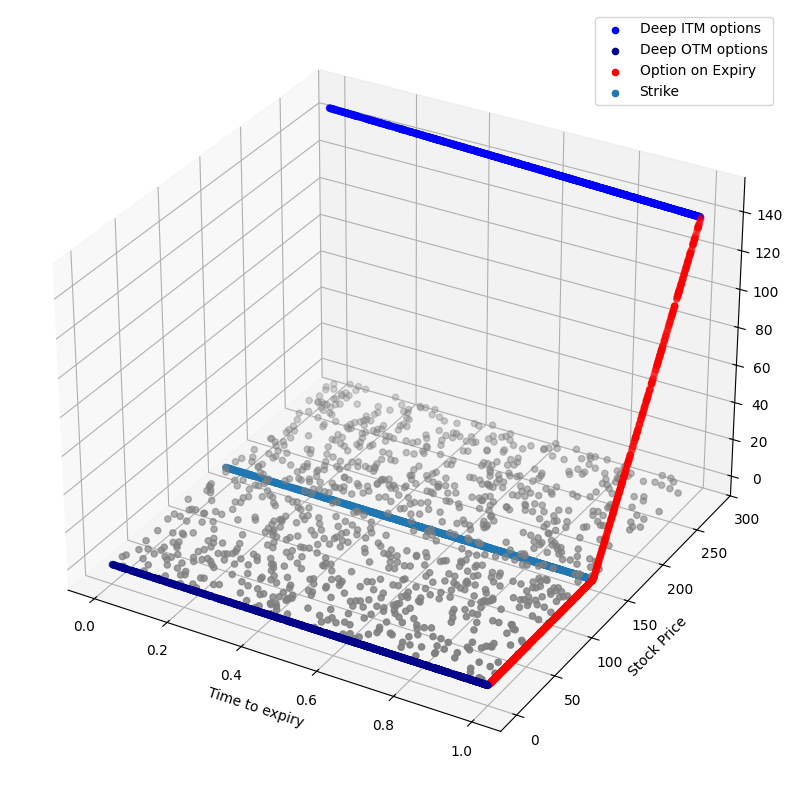

In [33]:
# # Expiry data points [Constraint on t]
# X_tn,y_tn = EndPoints(1000,K)

# # Data points for boundaries on S-> 0 and S-> infinity [Constraints on S]
# X_bottom,y_bottom,X_top,y_top = BoundaryPoints(1000, K,r,T)

# # PDE Data Points
# X_pde,y_pde = PDEPoints(1000)

# fig = plt.figure(figsize=(10,10))
# ax = plt.axes(projection = "3d")

# ax.scatter3D(X_pde[:,0],X_pde[:,1],y_pde,color = 'gray')
# ax.scatter3D(X_top[:,0],X_top[:,1],y_top, color = 'blue', label = 'Deep ITM options')
# ax.scatter3D(X_bottom[:,0],X_bottom[:,1], y_bottom, color = 'darkblue', label = 'Deep OTM options')
# ax.scatter3D(X_tn[:,0],X_tn[:,1], y_tn, color = 'red', label = 'Option on Expiry')
# ax.scatter3D(X_top[:,0],K,0, label = "Strike")
# plt.ylabel("Stock Price")
# plt.xlabel("Time to expiry")
# plt.legend()

# Expiry data points [Constraint on t]
X_tn,y_tn = EndPoints(1000,K)

# Data points for boundaries on S-> 0 and S-> infinity [Constraints on S]
X_bottom,y_bottom,X_top,y_top = BoundaryPoints(1000, K,r,T)

# PDE Data Points
X_pde,y_pde = PDEPoints(1000)

fig = plt.figure(figsize=(10,10))
ax = plt.axes(projection = "3d")

# Add .flatten() to all the y arrays so their shape matches X[:,0]
ax.scatter3D(X_pde[:,0], X_pde[:,1], y_pde.flatten(), color='gray')
ax.scatter3D(X_top[:,0], X_top[:,1], y_top.flatten(), color='blue', label='Deep ITM options')
ax.scatter3D(X_bottom[:,0], X_bottom[:,1], y_bottom.flatten(), color='darkblue', label='Deep OTM options')
ax.scatter3D(X_tn[:,0], X_tn[:,1], y_tn.flatten(), color='red', label='Option on Expiry')
ax.scatter3D(X_top[:,0], K, 0, label="Strike")

plt.ylabel("Stock Price")
plt.xlabel("Time to expiry")

# Hardcoded the location to prevent your previous performance warning!
plt.legend(loc="upper right")

Neural Network

In [34]:
# Shifted ELU function:
class shiftedELU(nn.Module):
    def __init__(self,alpha = 0.001,K=0):
        super(shiftedELU,self).__init__()
        self.alpha = alpha
        self.K = K
        self.ELU = nn.ELU(alpha)

    def forward(self, x):
        return self.ELU(x-self.K)

In [35]:
class Gated_PINN(nn.Module):
    def __init__(self):
        super(Gated_PINN, self).__init__()
        self.K = K

        # Define 9 individual models
        self.models = nn.ModuleList([self.create_single_model() for _ in range(9)])

        # Right branch
        self.model_right = nn.Sequential(
            nn.Linear(2, 5),
            nn.Sigmoid(),
            nn.Linear(5, 9),
            nn.Softmax(dim=1)
        )

    def create_single_model(self):
        # Left branch of a single model (Softplus)
        left_branch = nn.Sequential(
            nn.Linear(1, 5),
            nn.Softplus()
        )

        # Right branch of a single model (Sigmoid)
        right_branch = nn.Sequential(
            nn.Linear(1, 5),
            nn.Sigmoid()
        )

        return nn.ModuleDict({
            'left': left_branch,
            'right': right_branch,
            'output': nn.Sequential(
                nn.Linear(5, 1, bias=False)  # Equivalent to use_bias=False in Keras
            )
        })

    def forward(self, x):
        # Process left branch (concatenation of all 9 sub-models)
        # Split the input into (t, spot)
        t = x[:, 0].unsqueeze(1)  # Reshape to (batch_size, 1)
        spot = x[:, 1].unsqueeze(1)  # Reshape to (batch_size, 1)

        # Recombine t and transformed spot
        x = torch.cat((t, spot-self.K), dim=1)

        x_left = x[:,0].view(-1, 1)
        x_right = x[:,1].view(-1, 1)

        left_outputs = []
        for model in self.models:
            left_out = model['left'](x_left)
            right_out = model['right'](x_right)
            merged_out = left_out * right_out  # Element-wise multiplication
            final_out = model['output'](merged_out)
            left_outputs.append(final_out)

        # Concatenate the 9 outputs
        left_concatenated = torch.cat(left_outputs, dim=1)

        # Process right branch
        right_out = self.model_right(x)

        # Dot product of left and right branches
        dot_output = torch.sum(left_concatenated * right_out, dim=1, keepdim=True)

        return dot_output

In [36]:
# class PINN(nn.Module):
#     def __init__(self, input_size, output_size, hidden_size, n_layers, strike=K, sigma = sigma):
#         super(PINN,self).__init__()
#         self.K = strike
#         self.activation1 = nn.Sigmoid()
#         self.activation2 = nn.Softplus()

#         self.activation3 = nn.ELU(alpha=.01)
#         self.activation4 =  nn.Tanh() # best practices // torch.sqrt(sigma)*100*
#         self.activation5 = nn.ReLU()


#         self.fc_in = nn.Sequential(*[nn.Linear(in_features=input_size,out_features=hidden_size)])
#         self.fc_hidden = nn.Sequential(*[nn.Sequential(*[nn.Linear(hidden_size,hidden_size),self.activation4]) for _ in range(n_layers)])
#         self.fc_out = nn.Linear(in_features=hidden_size, out_features=output_size)

#         self.fc_in2 = nn.Sequential(*[nn.Linear(in_features=input_size,out_features=hidden_size)])
#         self.w = nn.Parameter(torch.tensor(1.0, requires_grad=True))

#         # Weight constraint for non-negative weights
#         self.non_neg_constraint()

#     def non_neg_constraint(self):
#         for param in self.parameters():
#             with torch.no_grad():
#                 param.clamp_(min=0)  # Ensures non-negative weights

#     def forward(self, x):
#         # convert input to (t,IV) pair:
#         # Split the input into (t, spot)
#         t = x[:, 0].unsqueeze(1)  # Reshape to (batch_size, 1)
#         spot = x[:, 1].unsqueeze(1)  # Reshape to (batch_size, 1)

#         # Recombine t and transformed spot
#         transformed_input = torch.cat((t, spot-self.K), dim=1)
#         IV = self.activation5(spot-self.K) # Apply shifted ELU to spot only to find Intrinsic value

#         # Using Tanh activation for nonlinearity and differentiablity:
#         inputs = self.fc_in(transformed_input)
#         hidden = inputs

#         for layer in self.fc_hidden:
#             hidden = layer(hidden)+hidden

#         # tranform hidden to output:
#         output = self.fc_out(hidden) + IV

#         return output

class StablePINN(nn.Module):
    def __init__(self, strike=K, T_max=T):
        super(StablePINN, self).__init__()
        self.K = strike
        self.T = T_max

        # 3-layer MLP with 64 hidden units is the standard benchmark for Black-Scholes PINNs
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        t = x[:, 0:1]
        S = x[:, 1:2]

        # 1. Feature normalization (keeps inputs in [-1, 1] range to stabilize 2nd/3rd derivatives)
        t_norm = (t - (self.T / 2)) / (self.T / 2)
        S_norm = (S - self.K) / self.K
        x_norm = torch.cat([t_norm, S_norm], dim=1)

        # 2. Network predicts the time-value premium scaled by strike K
        time_value = self.net(x_norm) * (self.K * 0.1)

        # 3. Intrinsic value skip connection: max(S - K, 0)
        IV = torch.relu(S - self.K)

        return time_value + IV

Loss Function to Minimize

In [37]:
mseloss = nn.MSELoss()
def pde_loss(outputs, inputs, sigma, r):
    # input = [t,S]
    frist_order = tgrad.grad(inputs = inputs, outputs=outputs.to(device), grad_outputs=torch.ones(outputs.shape).to(device),create_graph=True,retain_graph=True)[0]
    dC_dt = frist_order[:,0].view(-1,1)
    dC_dS = frist_order[:,1].view(-1,1)
    second_order = tgrad.grad(inputs=inputs,outputs=dC_dS.to(device),grad_outputs=torch.ones(dC_dS.shape).to(device),create_graph=True)[0]
    dC2_dS2 = second_order[:,1].view(-1,1)

    S = inputs[:,1].view(-1,1)
    # return PDE loss
    return mseloss(dC_dt + .5*dC2_dS2*pow(sigma*S,2) + r*S*dC_dS, r*outputs)

def boundary_loss(pred, labels):
    return mseloss(pred,labels)

def pinn_loss(pde_loss,boundary_loss):
    return pde_loss + boundary_loss

Training

In [38]:
# Model
# pinn = PINN(input_size=2,output_size=1,hidden_size=128, n_layers=4)
# pinn = PINN(input_size=2, output_size=1, hidden_size=128, n_layers=4, strike=K, sigma=sigma)
# pinn.to(device)
pinn = StablePINN(strike=K, T_max=T).to(device)
optimizer = optim.Adam(pinn.parameters(), lr=0.001)

In [39]:
loss_history = []
MSE_losses = [] # t=0 loss, S=infintiy loss, S=0 loss, PDE loss

In [40]:
print('Strike:',K)
print('Sigma:',sigma)
print('R:',r)

Strike: 140
Sigma: 0.18899999999999997
R: 0.0492


Initial training using Adam optimizer

In [41]:
# Define parameters
# Use the PINN class with the intrinsic value residual

# Reset your optimizer with the new parameters
optimizer = optim.Adam(pinn.parameters(), lr=0.0009)
lr_loss_weight = .1
# physics_lr = 100
# expiry_lr = 20
loss_weight = torch.nn.Parameter(torch.from_numpy(np.array([1,1,1,1])).float()) # weigths of initial loss, boundary loss S= Large, Boundary Loss S = 0, PDE loss
# epochs = 3000
start =0

# Balanced loss scaling
physics_lr = 1.0
expiry_lr = 1.0
epochs = 3000

loss_history = []
MSE_losses = []

for itr in range(epochs):
    pinn.train()

    # 1. Generate Collocation and Boundary Points
    X_tn, y_tn = EndPoints(1000, K)
    X_tn = torch.from_numpy(X_tn).float().to(device)
    y_tn = torch.from_numpy(y_tn).float().to(device)

    X_bottom, y_bottom, X_top, y_top = BoundaryPoints(1000, K, r, T)
    X_bottom = torch.from_numpy(X_bottom).float().to(device)
    y_bottom = torch.from_numpy(y_bottom).float().to(device)
    X_top = torch.from_numpy(X_top).float().to(device)
    y_top = torch.from_numpy(y_top).float().to(device)

    X_pde, _ = PDEPoints(2500)
    X_pde = torch.from_numpy(X_pde).float().requires_grad_().to(device)

    # 2. Compute Predictions
    C_pde = pinn(X_pde)
    C_tn = pinn(X_tn)
    C_top = pinn(X_top)
    C_bottom = pinn(X_bottom)

    # 3. Compute Residual Losses
    pde_l = physics_lr * pde_loss(C_pde, X_pde, sigma, r)
    tn_l = expiry_lr * boundary_loss(C_tn, y_tn)
    sN_l = boundary_loss(C_top, y_top)
    s0_l = boundary_loss(C_bottom, y_bottom)

    total_loss = tn_l + sN_l + s0_l + pde_l
    MSE_losses.append([tn_l.item(), sN_l.item(), s0_l.item(), pde_l.item()])

    # 4. Optimization step with Gradient Clipping
    optimizer.zero_grad()
    total_loss.backward()
    torch.nn.utils.clip_grad_norm_(pinn.parameters(), max_norm=1.0)
    optimizer.step()

    loss_history.append(total_loss.item())

    if (itr + 1) % 50 == 0 or itr == 0:
        print(f"Epoch {itr+1}/{epochs} | Total Loss: {total_loss.item():.4f} "
              f"[Expiry: {tn_l.item():.4f}] [S=Max: {sN_l.item():.4f}] "
              f"[S=0: {s0_l.item():.4f}] [PDE: {pde_l.item():.4f}]")

    if total_loss.item() < 0.05:
        print(f"Converged at epoch {itr+1}!")
        break
# for itr in range(epochs):
#     pinn.train()
#     i = itr + start
#     # generate new random data every iteration and converting to tensors
#     X_tn,y_tn = EndPoints(1000,K) # Expiry data points [Constraint on t]
#     X_tn = torch.from_numpy(X_tn).float().to(device)
#     y_tn = torch.from_numpy(y_tn).float().to(device)

#     X_bottom,y_bottom,X_top,y_top = BoundaryPoints(1000, K,r,T) # Data points for boundaries on S-> 0 and S-> infinity [Constraints on S]
#     X_bottom = torch.from_numpy(X_bottom).float().to(device)
#     y_bottom = torch.from_numpy(y_bottom).float().to(device)
#     X_top = torch.from_numpy(X_top).float().to(device)
#     y_top = torch.from_numpy(y_top).float().to(device)

#     X_pde,_ = PDEPoints(2500) # PDE Data Points
#     X_pde = torch.from_numpy(X_pde).float().requires_grad_().to(device)

#     # pde loss
#     C_pde = pinn(X_pde).to(device)
#     pde_losses = physics_lr*pde_loss(C_pde, X_pde, sigma, r)

#     # calculating indiviaul constraints loss
#     C_tn = pinn(X_tn).to(device)
#     tn_losses = expiry_lr*boundary_loss(C_tn,y_tn)
#     C_top = pinn(X_top).to(device)
#     sN_losses = boundary_loss(C_top,y_top)
#     C_bottom = pinn(X_bottom).to(device)
#     s0_losses = boundary_loss(C_bottom, y_bottom)

#     MSE_losses.append([tn_losses,sN_losses,s0_losses,pde_losses])
#     # updating parameters of NN to minimize weighted loss
#     optimizer.zero_grad()
#     loss = loss_weight[0]*tn_losses +  loss_weight[1]*sN_losses + loss_weight[2]*s0_losses + loss_weight[3]*pde_losses
#     loss.backward()
#     optimizer.step()

#     true_loss = tn_losses +  sN_losses + s0_losses + pde_losses
#     loss_history.append(true_loss)
#     # IF MSE loss is decreasing, update weigths [Used for fast initial convergence]
#     # if(i == 0 or(MSE_losses[i-1][0]>MSE_losses[i][0] and  MSE_losses[i-1][1]> MSE_losses[i][1] and MSE_losses[i-1][2]>MSE_losses[i][2] and MSE_losses[i-1][3]>MSE_losses[i][3])):
#     #     # weight gradients are MSE losses: Performing gradient ascent
#     #     loss_weight = loss_weight + lr_loss_weight*torch.tensor(MSE_losses[i])

#     print(f'Epoch {i+1}/{epochs} : loss: {true_loss} [Expiry {loss_weight[0]} {tn_losses}] [S=Large {loss_weight[1]} {sN_losses}] [S=0 {loss_weight[2]} {s0_losses}] [PDE {loss_weight[3]} {pde_losses}]')
#     if(true_loss<.5):
#       break

Epoch 1/3000 | Total Loss: 79.7605 [Expiry: 6.4655] [S=Max: 49.9792] [S=0: 1.0740] [PDE: 22.2417]
Epoch 50/3000 | Total Loss: 3.2695 [Expiry: 0.0206] [S=Max: 0.0331] [S=0: 0.1196] [PDE: 3.0962]
Epoch 100/3000 | Total Loss: 2.9774 [Expiry: 0.0616] [S=Max: 0.0563] [S=0: 0.0969] [PDE: 2.7626]
Epoch 150/3000 | Total Loss: 2.5620 [Expiry: 0.0398] [S=Max: 0.0617] [S=0: 0.0500] [PDE: 2.4104]
Epoch 200/3000 | Total Loss: 1.8598 [Expiry: 0.0675] [S=Max: 0.0745] [S=0: 0.0116] [PDE: 1.7061]
Epoch 250/3000 | Total Loss: 1.4148 [Expiry: 0.0275] [S=Max: 0.0343] [S=0: 0.0079] [PDE: 1.3452]
Epoch 300/3000 | Total Loss: 1.0849 [Expiry: 0.0734] [S=Max: 0.0087] [S=0: 0.0155] [PDE: 0.9873]
Epoch 350/3000 | Total Loss: 0.6943 [Expiry: 0.0151] [S=Max: 0.0055] [S=0: 0.0058] [PDE: 0.6680]
Epoch 400/3000 | Total Loss: 0.5717 [Expiry: 0.0274] [S=Max: 0.0380] [S=0: 0.0156] [PDE: 0.4906]
Epoch 450/3000 | Total Loss: 0.4555 [Expiry: 0.0209] [S=Max: 0.0268] [S=0: 0.0130] [PDE: 0.3948]
Epoch 500/3000 | Total Loss: 0

Plotting Loss

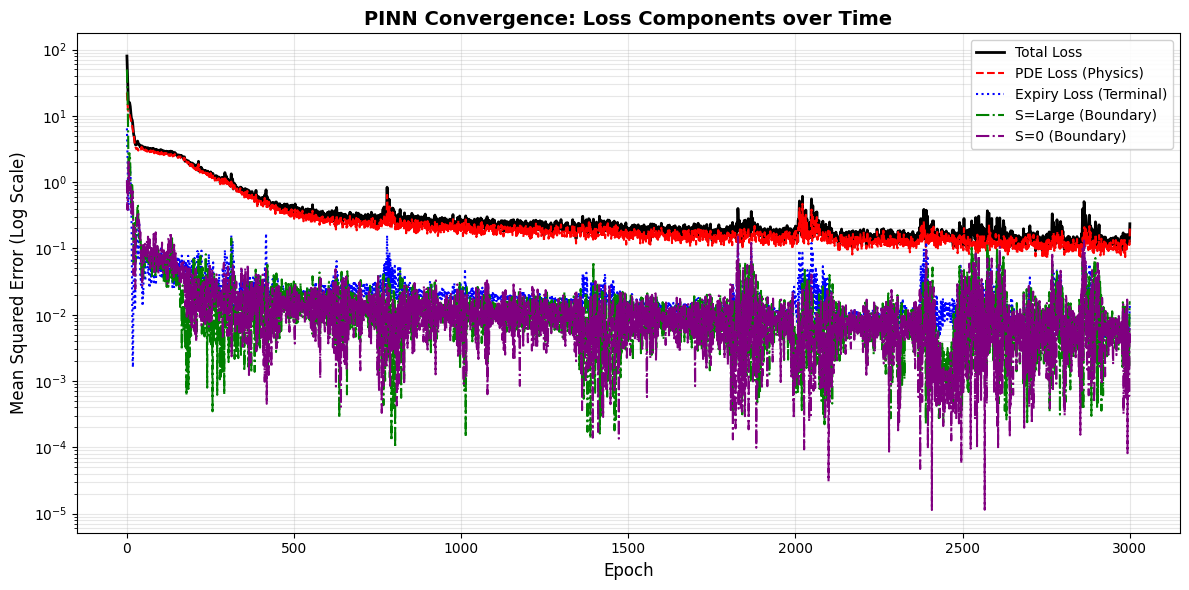

In [42]:
# # Convert MSE_losses to separate lists for each loss type
# expiry_losses = [loss[0].detach().cpu().numpy() for loss in MSE_losses]
# s_large_losses = [loss[1].detach().cpu().numpy() for loss in MSE_losses]
# s_zero_losses = [loss[2].detach().cpu().numpy() for loss in MSE_losses]
# pde_losses = [loss[3].detach().cpu().numpy() for loss in MSE_losses]

# # Convert loss_history to numpy
# total_loss = [loss.detach().cpu().numpy() for loss in loss_history]

# # Create an array of epochs (1 to epochs)
# epochs = np.arange(1, len(MSE_losses) + 1)

# # Plot each loss component
# plt.figure(figsize=(10,6))
# plt.plot(epochs, expiry_losses, label="Expiry")
# plt.plot(epochs, s_large_losses, label="S-Large")
# plt.plot(epochs, s_zero_losses, label="S=0")
# plt.plot(epochs, pde_losses, label="PDE")
# plt.plot(epochs, total_loss, label="Total Loss")

# # Add labels, title, and legend
# plt.xlabel('Epoch')
# plt.ylabel('Loss')
# plt.title('MSE Losses over Epochs')
# plt.legend()
# plt.yscale('log')
# # Show the plot
# plt.show()


# Using float() safely handles both PyTorch tensors and standard Python numbers
expiry_losses = [float(loss[0]) for loss in MSE_losses]
s_large_losses = [float(loss[1]) for loss in MSE_losses]
s_zero_losses = [float(loss[2]) for loss in MSE_losses]
pde_losses = [float(loss[3]) for loss in MSE_losses]

# loss_history already contains floats, but float() ensures consistency
total_loss_arr = [float(loss) for loss in loss_history]

# Create an array of epochs
epochs_arr = np.arange(1, len(total_loss_arr) + 1)

# Professional Quant-Style Plotting
plt.figure(figsize=(12, 6))

# Plot Total Loss with a strong, thick line
plt.plot(epochs_arr, total_loss_arr, label="Total Loss", color='black', linewidth=2)

# Plot components with distinct styles
plt.plot(epochs_arr, pde_losses, label="PDE Loss (Physics)", color='red', linestyle='--')
plt.plot(epochs_arr, expiry_losses, label="Expiry Loss (Terminal)", color='blue', linestyle=':')
plt.plot(epochs_arr, s_large_losses, label="S=Large (Boundary)", color='green', linestyle='-.')
plt.plot(epochs_arr, s_zero_losses, label="S=0 (Boundary)", color='purple', linestyle='-.')

# Formatting
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Mean Squared Error (Log Scale)', fontsize=12)
plt.title('PINN Convergence: Loss Components over Time', fontsize=14, fontweight='bold')
plt.legend(loc="upper right", framealpha=0.9)
plt.yscale('log')
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.tight_layout()

plt.show()

Analysis of pricing across time frame

In [43]:
def time_frame_analysis(time_frame):
    spots = np.linspace(K-140,K+140,100)
    # spots = np.linspace(S_range[0],S_range[1],100)
    t = np.array([time_frame]*spots.shape[0])

    # Calculate Pinn output
    X_test = torch.tensor(np.concatenate((t.reshape(-1,1),spots.reshape(-1,1)),axis=1)).float().to(device)
    with torch.no_grad():
        pinn.eval()
        y_pinn = pinn(X_test)

    # calculate output for BSM
    y_bsm = BSM_pricing(X_test[:,1],T-X_test[:,0],torch.tensor(K),torch.tensor(r),torch.tensor(sigma))
    plt.plot(spots,y_bsm.detach().cpu().numpy(),label = "BSM-pricing")
    plt.scatter(spots,y_pinn.detach().cpu().numpy(), s = 2, label = "PINN-pricing",color = "Red", marker='x')
    plt.title(f"Analysis of solution at t={time_frame}")

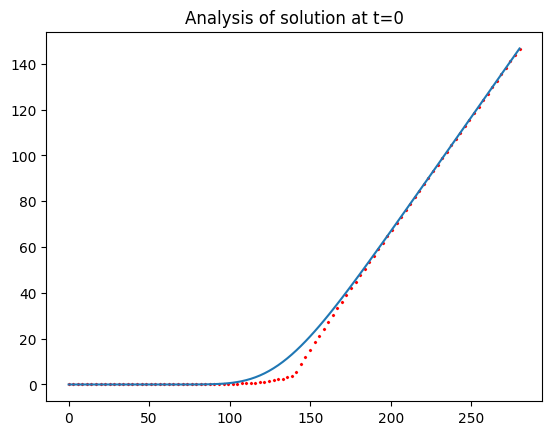

In [44]:
time_frame_analysis(0)

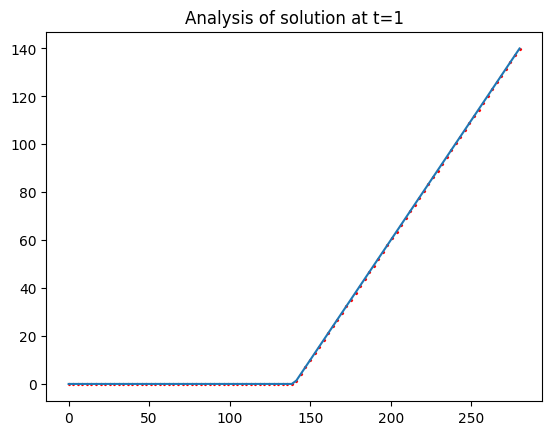

In [45]:
time_frame_analysis(1)

Analysis of PINNs vs BSM surface

In [46]:
s = np.linspace(0,S_range[1],1000)
t = np.linspace(0,T_range[1],1000)
s_grid, t_grid = np.meshgrid(s,t)


X_test = torch.Tensor(np.concatenate((t_grid.flatten().reshape(-1,1),s_grid.flatten().reshape(-1,1)),axis = 1)).float().to(device)
y_bsm_surface = BSM_pricing(X_test[:,1],X_test[:,0],torch.tensor(K),torch.tensor(r), torch.tensor(sigma))
with torch.no_grad():
    pinn.eval()
    y_pinn_surface = pinn(X_test)

MSE:  11.475624084472656


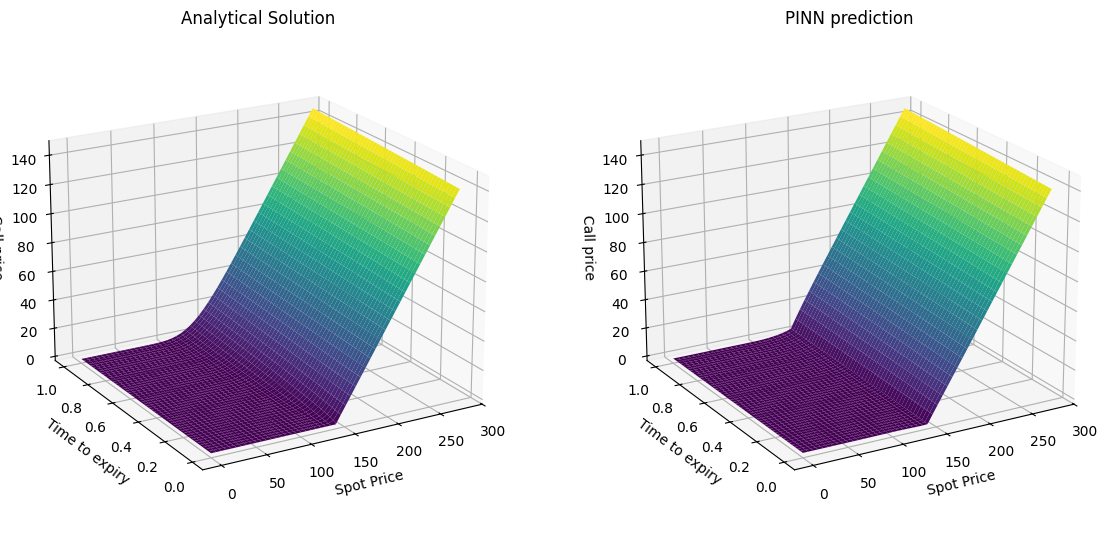

In [47]:
# Force both to identical 1D shapes to prevent 3.7TB broadcasting
print("MSE: ", mseloss(y_bsm_surface.view(-1), y_pinn_surface.view(-1)).item())

# Create the 3D plot
fig = plt.figure(figsize=(14,7))
ax = fig.add_subplot(121, projection='3d')
ax.plot_surface(s_grid, t_grid, y_bsm_surface.detach().cpu().numpy().reshape(s_grid.shape), cmap = "viridis")
ax.set_title("Analytical Solution")
ax.set_xlabel("Spot Price")
ax.set_ylabel("Time to expiry")
ax.set_zlabel("Call price")
ax.view_init(elev=20, azim=-120)

# Reverse the time grid for the PINN to mirror BSM's time
t_grid_pinn = 1 - t_grid
ax = fig.add_subplot(122, projection='3d')
ax.plot_surface(s_grid, t_grid_pinn, y_pinn_surface.detach().cpu().numpy().reshape(s_grid.shape), cmap = "viridis")
ax.set_title("PINN prediction")
ax.set_xlabel("Spot Price")
ax.set_ylabel("Time to expiry")
ax.set_zlabel("Call price")
ax.view_init(elev=20, azim=-120)

In [48]:
import yfinance as yf
import pandas as pd
import torch
import torch.nn as nn
import torch.autograd as tgrad
import torch.optim as optim

def get_live_option_data(ticker_symbol="AAPL"):
    ticker = yf.Ticker(ticker_symbol)
    S_live = ticker.history(period="1d")['Close'].iloc[-1]

    # Get the nearest expiration date
    expiries = ticker.options
    if not expiries:
        raise ValueError(f"No options available for {ticker_symbol}")
    nearest_expiry = expiries[0]

    # Fetch call options and filter out zero-volume contracts
    calls = ticker.option_chain(nearest_expiry).calls
    calls = calls[calls['volume'] > 0]

    # Calculate time to maturity in years
    expiry_date = pd.to_datetime(nearest_expiry)
    today = pd.to_datetime('today')
    t_to_expiry = max((expiry_date - today).days / 365.25, 0.005) # Prevent strict zero

    # Inputs: [t, S, K]
    t_tensor = torch.tensor([t_to_expiry] * len(calls), dtype=torch.float32).view(-1, 1)
    S_tensor = torch.tensor([S_live] * len(calls), dtype=torch.float32).view(-1, 1)
    K_tensor = torch.tensor(calls['strike'].values, dtype=torch.float32).view(-1, 1)

    X_market = torch.cat([t_tensor, S_tensor, K_tensor], dim=1).to(device)
    X_market.requires_grad_(True)

    # Target: Market Mid-Price
    market_prices = ((calls['bid'] + calls['ask']) / 2).values
    y_market = torch.tensor(market_prices, dtype=torch.float32).view(-1, 1).to(device)

    return X_market, y_market, S_live

X_market, y_market, S_live = get_live_option_data("AAPL")
print(f"Loaded {len(y_market)} live contracts. Current Spot: ${S_live:.2f}")

Loaded 62 live contracts. Current Spot: $328.21


In [49]:
class LocalVolPINN(nn.Module):
    def __init__(self):
        super(LocalVolPINN, self).__init__()

        # Price Sub-Network: Inputs [t, S, K]
        self.price_net = nn.Sequential(
            nn.Linear(3, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )

        # Volatility Sub-Network: Inputs [t, S, K]
        self.vol_net = nn.Sequential(
            nn.Linear(3, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1),
            nn.Softplus() # Enforces strictly positive volatility
        )

    def forward(self, x):
        t = x[:, 0:1]
        S = x[:, 1:2]
        K = x[:, 2:3]

        # Internal Normalization (Scale invariance for stability)
        t_norm = t / 2.0
        S_norm = S / 1000.0
        K_norm = K / 1000.0
        x_norm = torch.cat([t_norm, S_norm, K_norm], dim=1)

        # Predict Time Value Premium
        time_value = self.price_net(x_norm) * K * 0.1

        # Intrinsic Value Skip Connection
        IV = torch.relu(S - K)

        C_pred = time_value + IV
        # Add epsilon to prevent strict zero volatility (numerical stability)
        sigma_pred = self.vol_net(x_norm) + 1e-4

        return C_pred, sigma_pred

In [50]:
def live_market_loss(pinn_model, X_market, y_market, r_rate=0.05):
    C_pred, sigma_pred = pinn_model(X_market)

    # 1. Market Data Loss
    data_loss = nn.MSELoss()(C_pred, y_market)

    # Compute Autograd Derivatives
    first_order = tgrad.grad(C_pred, X_market, grad_outputs=torch.ones_like(C_pred), create_graph=True)[0]
    dC_dt = first_order[:, 0:1]
    dC_dS = first_order[:, 1:2]

    second_order = tgrad.grad(dC_dS, X_market, grad_outputs=torch.ones_like(dC_dS), create_graph=True)[0]
    d2C_dS2 = second_order[:, 1:2]

    S = X_market[:, 1:2]

    # 2. Local Volatility PDE Loss (Dupire's Forward relationship adapted for Black-Scholes)
    pde_residual = dC_dt + 0.5 * (sigma_pred * S)**2 * d2C_dS2 + r_rate * S * dC_dS - r_rate * C_pred
    pde_loss = nn.MSELoss()(pde_residual, torch.zeros_like(pde_residual))

    # 3. No-Arbitrage Penalties
    # Monotonicity (Delta >= 0): Penalize any negative dC/dS
    monotonicity_penalty = torch.mean(torch.relu(-dC_dS)**2)
    # Convexity (Gamma >= 0): Penalize any negative d2C/dS2
    convexity_penalty = torch.mean(torch.relu(-d2C_dS2)**2)

    arbitrage_loss = monotonicity_penalty + convexity_penalty

    return data_loss, pde_loss, arbitrage_loss

In [51]:
live_pinn = LocalVolPINN().to(device)
optimizer = optim.Adam(live_pinn.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=200)

lambda_data = 1.0
lambda_pde = 0.1
lambda_arb = 10.0

epochs = 3000
risk_free_rate = 0.05

for epoch in range(epochs):
    live_pinn.train()
    optimizer.zero_grad()

    # Compute multi-objective loss
    data_l, pde_l, arb_l = live_market_loss(live_pinn, X_market, y_market, risk_free_rate)

    total_loss = (lambda_data * data_l) + (lambda_pde * pde_l) + (lambda_arb * arb_l)

    total_loss.backward()
    torch.nn.utils.clip_grad_norm_(live_pinn.parameters(), max_norm=1.0)
    optimizer.step()

    scheduler.step(total_loss.item())

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Total: {total_loss.item():.4f} "
              f"[Data: {data_l.item():.4f}] [PDE: {pde_l.item():.4f}] [Arb: {arb_l.item():.4f}]")

print("Live Market Calibration Complete.")

Epoch 100/3000 | Total: 853.2531 [Data: 844.7878] [PDE: 84.6522] [Arb: 0.0000]
Epoch 200/3000 | Total: 39.2002 [Data: 35.5541] [PDE: 36.4613] [Arb: 0.0000]
Epoch 300/3000 | Total: 17.7735 [Data: 16.2618] [PDE: 15.1177] [Arb: 0.0000]
Epoch 400/3000 | Total: 5.1784 [Data: 4.2052] [PDE: 9.7299] [Arb: 0.0000]
Epoch 500/3000 | Total: 4.5432 [Data: 3.6991] [PDE: 8.4391] [Arb: 0.0000]
Epoch 600/3000 | Total: 3.2556 [Data: 2.4511] [PDE: 8.0420] [Arb: 0.0000]
Epoch 700/3000 | Total: 3.3448 [Data: 2.5841] [PDE: 7.6040] [Arb: 0.0000]
Epoch 800/3000 | Total: 2.6420 [Data: 1.9186] [PDE: 7.2311] [Arb: 0.0000]
Epoch 900/3000 | Total: 2.7683 [Data: 2.0794] [PDE: 6.8866] [Arb: 0.0000]
Epoch 1000/3000 | Total: 2.3181 [Data: 1.6547] [PDE: 6.6307] [Arb: 0.0000]
Epoch 1100/3000 | Total: 2.7992 [Data: 2.1146] [PDE: 6.8439] [Arb: 0.0000]
Epoch 1200/3000 | Total: 2.9700 [Data: 2.0167] [PDE: 9.5310] [Arb: 0.0000]
Epoch 1300/3000 | Total: 2.0096 [Data: 1.4152] [PDE: 5.9416] [Arb: 0.0000]
Epoch 1400/3000 | Total

In [52]:
# Reproducibility
import random
import time
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Device:", device)
print("Random seed:", SEED)

Device: cuda:0
Random seed: 42


In [53]:
def bsm_from_elapsed_time(S, elapsed_t, K, T, r, sigma):
    """
    Black-Scholes analytical price using the same time convention
    as the PINN: elapsed time t, where tau = T - t.
    """
    tau = torch.clamp(
        torch.as_tensor(T, dtype=S.dtype, device=S.device) - elapsed_t,
        min=1e-8
    )

    return BSM_pricing(
        S,
        tau,
        torch.as_tensor(K, dtype=S.dtype, device=S.device),
        torch.as_tensor(r, dtype=S.dtype, device=S.device),
        torch.as_tensor(sigma, dtype=S.dtype, device=S.device)
    )

In [54]:
# Independent evaluation grid
N_S = 250
N_T = 100

S_test_np = np.linspace(
    max(1e-4, S_range[0]),
    S_range[1],
    N_S
)

t_test_np = np.linspace(
    T_range[0],
    T_range[1] - 1e-5,
    N_T
)

S_grid_eval, t_grid_eval = np.meshgrid(S_test_np, t_test_np)

X_eval = torch.tensor(
    np.column_stack([
        t_grid_eval.ravel(),
        S_grid_eval.ravel()
    ]),
    dtype=torch.float32,
    device=device
)

with torch.no_grad():
    pinn.eval()
    y_pinn_eval = pinn(X_eval).view(-1)

y_bsm_eval = bsm_from_elapsed_time(
    X_eval[:, 1],
    X_eval[:, 0],
    K,
    T,
    r,
    sigma
).view(-1)

print("Evaluation points:", len(X_eval))
print("PINN predictions:", y_pinn_eval.shape)
print("BSM reference:", y_bsm_eval.shape)

Evaluation points: 25000
PINN predictions: torch.Size([25000])
BSM reference: torch.Size([25000])


In [55]:
def regression_metrics(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)

    error = y_pred - y_true
    abs_error = np.abs(error)

    return {
        "MSE": np.mean(error ** 2),
        "RMSE": np.sqrt(np.mean(error ** 2)),
        "MAE": np.mean(abs_error),
        "Max Absolute Error": np.max(abs_error),
        "Mean Relative Error (%)":
            np.mean(abs_error / np.maximum(np.abs(y_true), eps)) * 100,
        "Median Relative Error (%)":
            np.median(abs_error / np.maximum(np.abs(y_true), eps)) * 100,
        "R2":
            1 - np.sum(error ** 2) /
            np.maximum(np.sum((y_true - np.mean(y_true)) ** 2), eps)
    }


metrics_pinn = regression_metrics(
    y_bsm_eval.detach().cpu().numpy(),
    y_pinn_eval.detach().cpu().numpy()
)

metrics_df = pd.DataFrame(
    metrics_pinn.items(),
    columns=["Metric", "PINN"]
)

display(metrics_df)

,Metric,PINN
0,MSE,2.661546e+00
1,RMSE,1.631424e+00
2,MAE,6.180779e-01
3,Max Absolute Error,9.825590e+00
4,Mean Relative Error (%),9.952760e+07
5,Median Relative Error (%),4.283653e+01
6,R2,9.987606e-01


In [56]:
def regression_metrics(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)

    error = y_pred - y_true
    abs_error = np.abs(error)

    return {
        "MSE": np.mean(error ** 2),
        "RMSE": np.sqrt(np.mean(error ** 2)),
        "MAE": np.mean(abs_error),
        "Max Absolute Error": np.max(abs_error),
        "Mean Relative Error (%)":
            np.mean(abs_error / np.maximum(np.abs(y_true), eps)) * 100,
        "Median Relative Error (%)":
            np.median(abs_error / np.maximum(np.abs(y_true), eps)) * 100,
        "R2":
            1 - np.sum(error ** 2) /
            np.maximum(np.sum((y_true - np.mean(y_true)) ** 2), eps)
    }


metrics_pinn = regression_metrics(
    y_bsm_eval.detach().cpu().numpy(),
    y_pinn_eval.detach().cpu().numpy()
)

metrics_df = pd.DataFrame(
    metrics_pinn.items(),
    columns=["Metric", "PINN"]
)

display(metrics_df)

,Metric,PINN
0,MSE,2.661546e+00
1,RMSE,1.631424e+00
2,MAE,6.180779e-01
3,Max Absolute Error,9.825590e+00
4,Mean Relative Error (%),9.952760e+07
5,Median Relative Error (%),4.283653e+01
6,R2,9.987606e-01


In [57]:
class DataDrivenNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        t = x[:, 0:1]
        S = x[:, 1:2]

        # Same normalization used by StablePINN
        t_norm = (t - T / 2) / (T / 2)
        S_norm = (S - K) / K

        return self.net(torch.cat([t_norm, S_norm], dim=1)) * (K * 0.1)

In [58]:
# Small labelled dataset for the conventional NN
N_SUPERVISED = 2000

rng = np.random.default_rng(SEED)

t_train = rng.uniform(
    T_range[0],
    T_range[1] - 1e-5,
    N_SUPERVISED
)

S_train = rng.uniform(
    S_range[0],
    S_range[1],
    N_SUPERVISED
)

X_train_nn = torch.tensor(
    np.column_stack([t_train, S_train]),
    dtype=torch.float32,
    device=device
)

y_train_nn = bsm_from_elapsed_time(
    X_train_nn[:, 1],
    X_train_nn[:, 0],
    K,
    T,
    r,
    sigma
).view(-1, 1).detach()

print("Supervised training samples:", N_SUPERVISED)

Supervised training samples: 2000


In [59]:
baseline_nn = DataDrivenNN().to(device)

baseline_optimizer = optim.Adam(
    baseline_nn.parameters(),
    lr=1e-3
)

baseline_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    baseline_optimizer,
    mode="min",
    factor=0.5,
    patience=200
)

baseline_history = []

EPOCHS_BASELINE = 3000

start_time = time.time()

for epoch in range(EPOCHS_BASELINE):

    baseline_nn.train()
    baseline_optimizer.zero_grad()

    prediction = baseline_nn(X_train_nn)

    loss = nn.MSELoss()(prediction, y_train_nn)

    loss.backward()

    torch.nn.utils.clip_grad_norm_(
        baseline_nn.parameters(),
        max_norm=1.0
    )

    baseline_optimizer.step()
    baseline_scheduler.step(loss.item())

    baseline_history.append(loss.item())

    if (epoch + 1) % 500 == 0:
        print(
            f"Epoch {epoch+1}/{EPOCHS_BASELINE} | "
            f"Loss: {loss.item():.6f}"
        )

baseline_training_time = time.time() - start_time

print(f"\nBaseline training time: {baseline_training_time:.2f} seconds")

Epoch 500/3000 | Loss: 0.622999
Epoch 1000/3000 | Loss: 0.220584
Epoch 1500/3000 | Loss: 0.297529
Epoch 2000/3000 | Loss: 0.045306
Epoch 2500/3000 | Loss: 0.034353
Epoch 3000/3000 | Loss: 0.015733

Baseline training time: 4.67 seconds


In [60]:
with torch.no_grad():
    baseline_nn.eval()
    y_baseline_eval = baseline_nn(X_eval).view(-1)

baseline_metrics = regression_metrics(
    y_bsm_eval.detach().cpu().numpy(),
    y_baseline_eval.detach().cpu().numpy()
)

comparison_df = pd.DataFrame({
    "Metric": list(metrics_pinn.keys()),
    "PINN": list(metrics_pinn.values()),
    "Data-Driven NN": list(baseline_metrics.values())
})

display(comparison_df)

,Metric,PINN,Data-Driven NN
0,MSE,2.661546e+00,1.319248e-02
1,RMSE,1.631424e+00,1.148585e-01
2,MAE,6.180779e-01,7.200140e-02
3,Max Absolute Error,9.825590e+00,2.443418e+00
4,Mean Relative Error (%),9.952760e+07,1.621218e+08
5,Median Relative Error (%),4.283653e+01,8.185506e-01
6,R2,9.987606e-01,9.999939e-01


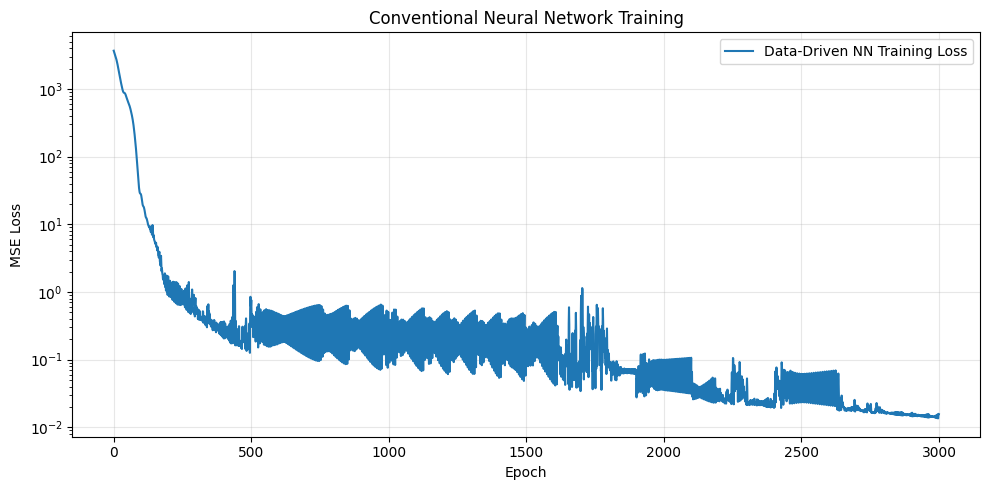

In [61]:
plt.figure(figsize=(10, 5))

plt.plot(
    baseline_history,
    label="Data-Driven NN Training Loss"
)

plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Conventional Neural Network Training")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

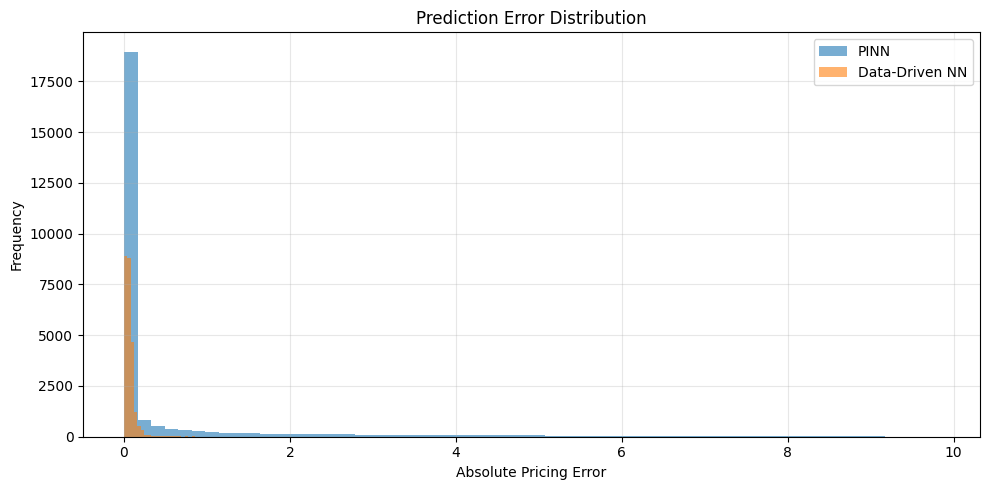

In [62]:
true_np = y_bsm_eval.detach().cpu().numpy()
pinn_np = y_pinn_eval.detach().cpu().numpy()
baseline_np = y_baseline_eval.detach().cpu().numpy()

pinn_abs_error = np.abs(pinn_np - true_np)
baseline_abs_error = np.abs(baseline_np - true_np)

plt.figure(figsize=(10, 5))

plt.hist(
    pinn_abs_error,
    bins=60,
    alpha=0.6,
    label="PINN"
)

plt.hist(
    baseline_abs_error,
    bins=60,
    alpha=0.6,
    label="Data-Driven NN"
)

plt.xlabel("Absolute Pricing Error")
plt.ylabel("Frequency")
plt.title("Prediction Error Distribution")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [63]:
eval_df = pd.DataFrame({
    "t": X_eval[:, 0].detach().cpu().numpy(),
    "S": X_eval[:, 1].detach().cpu().numpy(),
    "BSM": true_np,
    "PINN": pinn_np,
    "Baseline": baseline_np
})

eval_df["Moneyness"] = eval_df["S"] / K
eval_df["PINN_Abs_Error"] = np.abs(
    eval_df["PINN"] - eval_df["BSM"]
)

eval_df["Baseline_Abs_Error"] = np.abs(
    eval_df["Baseline"] - eval_df["BSM"]
)

moneyness_bins = [
    0.0, 0.8, 0.9, 0.95, 1.0,
    1.05, 1.10, 1.20, 10.0
]

moneyness_labels = [
    "<0.80",
    "0.80–0.90",
    "0.90–0.95",
    "0.95–1.00",
    "1.00–1.05",
    "1.05–1.10",
    "1.10–1.20",
    ">1.20"
]

eval_df["Moneyness_Bin"] = pd.cut(
    eval_df["Moneyness"],
    bins=moneyness_bins,
    labels=moneyness_labels,
    include_lowest=True
)

moneyness_results = (
    eval_df
    .groupby("Moneyness_Bin", observed=True)
    .agg(
        PINN_MAE=("PINN_Abs_Error", "mean"),
        Baseline_MAE=("Baseline_Abs_Error", "mean"),
        Samples=("PINN_Abs_Error", "size")
    )
    .reset_index()
)

display(moneyness_results)

,Moneyness_Bin,PINN_MAE,Baseline_MAE,Samples
0,<0.80,0.074822,0.059840,10000
1,0.80–0.90,1.321911,0.088411,1300
2,0.90–0.95,3.331969,0.083974,600
3,0.95–1.00,5.477801,0.173544,600
4,1.00–1.05,5.282824,0.127398,600
5,1.05–1.10,3.066945,0.087787,600
6,1.10–1.20,1.336350,0.146443,1300
7,>1.20,0.095227,0.061270,10000


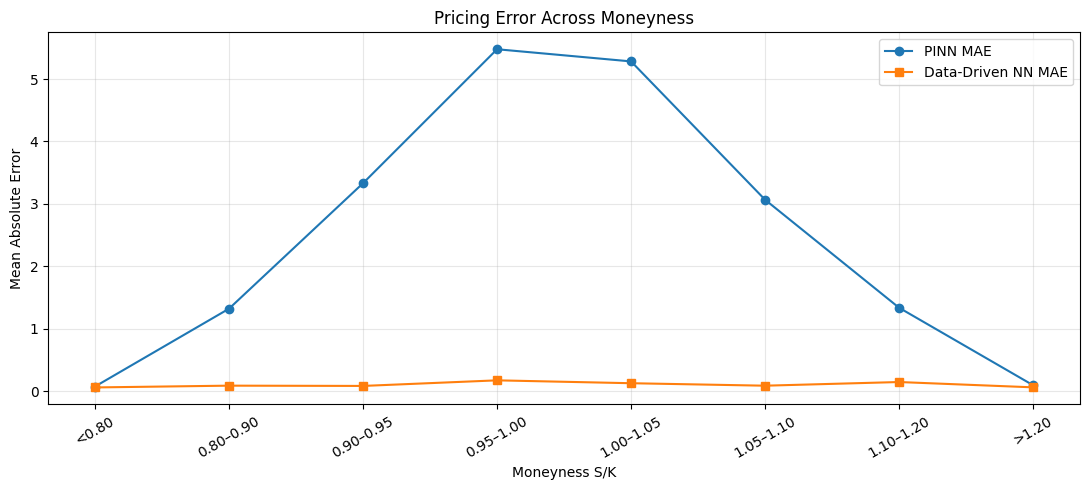

In [64]:
plt.figure(figsize=(11, 5))

x = np.arange(len(moneyness_results))

plt.plot(
    x,
    moneyness_results["PINN_MAE"],
    marker="o",
    label="PINN MAE"
)

plt.plot(
    x,
    moneyness_results["Baseline_MAE"],
    marker="s",
    label="Data-Driven NN MAE"
)

plt.xticks(
    x,
    moneyness_results["Moneyness_Bin"],
    rotation=30
)

plt.xlabel("Moneyness S/K")
plt.ylabel("Mean Absolute Error")
plt.title("Pricing Error Across Moneyness")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [65]:
eval_df["PINN_Rel_Error_%"] = (
    eval_df["PINN_Abs_Error"] /
    np.maximum(np.abs(eval_df["BSM"]), 1e-6)
) * 100

eval_df["Baseline_Rel_Error_%"] = (
    eval_df["Baseline_Abs_Error"] /
    np.maximum(np.abs(eval_df["BSM"]), 1e-6)
) * 100

time_bins = np.linspace(
    T_range[0],
    T_range[1],
    11
)

eval_df["Time_Bin"] = pd.cut(
    eval_df["t"],
    bins=time_bins,
    include_lowest=True
)

time_results = (
    eval_df
    .groupby("Time_Bin", observed=True)
    .agg(
        PINN_MAE=("PINN_Abs_Error", "mean"),
        Baseline_MAE=("Baseline_Abs_Error", "mean"),
        PINN_Rel_Error=("PINN_Rel_Error_%", "mean"),
        Baseline_Rel_Error=("Baseline_Rel_Error_%", "mean"),
        Samples=("PINN_Abs_Error", "size")
    )
    .reset_index()
)

display(time_results)

,Time_Bin,PINN_MAE,Baseline_MAE,PINN_Rel_Error,Baseline_Rel_Error,Samples
0,"(-0.001, 0.1]",1.127598,0.085317,1.640159e+06,1.717981e+06,2500
1,"(0.1, 0.2]",1.018692,0.044458,1.564192e+06,6.768126e+05,2500
2,"(0.2, 0.3]",0.908108,0.034465,1.481928e+06,3.482212e+05,2500
3,"(0.3, 0.4]",0.794628,0.049620,1.371892e+06,1.066524e+06,2500
4,"(0.4, 0.5]",0.677795,0.065047,1.207411e+06,1.684771e+06,2500
5,"(0.5, 0.6]",0.559096,0.076815,1.070185e+06,2.097081e+06,2500
6,"(0.6, 0.7]",0.444242,0.078796,9.230591e+05,2.121029e+06,2500
7,"(0.7, 0.8]",0.330522,0.061996,7.846277e+05,1.587413e+06,2500
8,"(0.8, 0.9]",0.216236,0.057402,6.160129e+05,1.041559e+06,2500
9,"(0.9, 1.0]",0.103862,0.166098,8.977786e+05,5.726538e+06,2500


In [66]:
def evaluate_constraints(model, n=500):
    model.eval()

    t_vals = torch.linspace(
        0,
        T - 1e-5,
        n,
        device=device
    ).view(-1, 1)

    # S = 0
    X_zero = torch.cat(
        [t_vals, torch.zeros_like(t_vals)],
        dim=1
    )

    # S = maximum boundary
    S_max = torch.full_like(t_vals, float(S_range[1]))

    X_large = torch.cat(
        [t_vals, S_max],
        dim=1
    )

    # Terminal condition
    S_terminal = torch.linspace(
        S_range[0],
        S_range[1],
        n,
        device=device
    ).view(-1, 1)

    t_terminal = torch.full_like(
        S_terminal,
        float(T)
    )

    X_terminal = torch.cat(
        [t_terminal, S_terminal],
        dim=1
    )

    with torch.no_grad():
        pred_zero = model(X_zero)
        pred_large = model(X_large)
        pred_terminal = model(X_terminal)

    target_zero = torch.zeros_like(pred_zero)

    target_large = (
        S_max -
        K * torch.exp(-r * (T - t_vals))
    )

    target_terminal = torch.relu(
        S_terminal - K
    )

    return {
        "S=0 MAE":
            torch.mean(
                torch.abs(pred_zero - target_zero)
            ).item(),

        "S=max MAE":
            torch.mean(
                torch.abs(pred_large - target_large)
            ).item(),

        "Terminal MAE":
            torch.mean(
                torch.abs(pred_terminal - target_terminal)
            ).item()
    }


constraint_results = evaluate_constraints(pinn)

display(
    pd.DataFrame(
        constraint_results.items(),
        columns=["Constraint", "MAE"]
    )
)

,Constraint,MAE
0,S=0 MAE,0.060683
1,S=max MAE,0.027376
2,Terminal MAE,0.057252


In [67]:
def calculate_pde_residual(model, X, sigma_value=sigma, r_value=r):
    X = X.clone().detach().requires_grad_(True)

    output = model(X)

    first_order = torch.autograd.grad(
        output,
        X,
        grad_outputs=torch.ones_like(output),
        create_graph=True
    )[0]

    dC_dt = first_order[:, 0:1]
    dC_dS = first_order[:, 1:2]

    second_order = torch.autograd.grad(
        dC_dS,
        X,
        grad_outputs=torch.ones_like(dC_dS),
        create_graph=True
    )[0]

    d2C_dS2 = second_order[:, 1:2]

    S = X[:, 1:2]

    residual = (
        dC_dt
        + 0.5 * (sigma_value * S) ** 2 * d2C_dS2
        + r_value * S * dC_dS
        - r_value * output
    )

    return residual.detach()


# Independent random PDE evaluation points
N_PDE_TEST = 5000

X_pde_test = torch.tensor(
    np.column_stack([
        np.random.uniform(0, T - 1e-5, N_PDE_TEST),
        np.random.uniform(S_range[0], S_range[1], N_PDE_TEST)
    ]),
    dtype=torch.float32,
    device=device
)

pde_residual = calculate_pde_residual(
    pinn,
    X_pde_test
)

pde_metrics = {
    "Mean |PDE residual|":
        torch.mean(torch.abs(pde_residual)).item(),

    "RMS PDE residual":
        torch.sqrt(torch.mean(pde_residual ** 2)).item(),

    "Maximum |PDE residual|":
        torch.max(torch.abs(pde_residual)).item()
}

display(
    pd.DataFrame(
        pde_metrics.items(),
        columns=["Metric", "Value"]
    )
)

,Metric,Value
0,Mean |PDE residual|,0.211796
1,RMS PDE residual,0.390205
2,Maximum |PDE residual|,4.130083


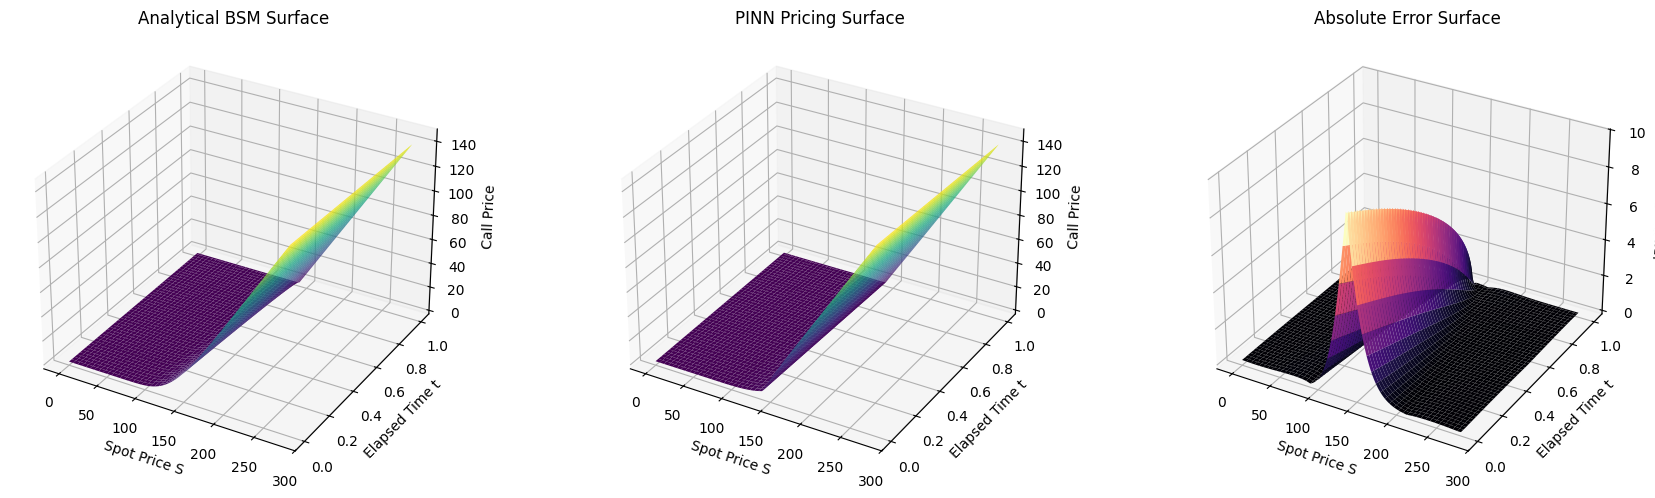

In [68]:
# Reshape evaluation values
bsm_surface = true_np.reshape(t_grid_eval.shape)
pinn_surface = pinn_np.reshape(t_grid_eval.shape)

error_surface = np.abs(
    pinn_surface - bsm_surface
)

fig = plt.figure(figsize=(18, 5))

ax1 = fig.add_subplot(131, projection="3d")
ax1.plot_surface(
    S_grid_eval,
    t_grid_eval,
    bsm_surface,
    cmap="viridis"
)
ax1.set_title("Analytical BSM Surface")
ax1.set_xlabel("Spot Price S")
ax1.set_ylabel("Elapsed Time t")
ax1.set_zlabel("Call Price")

ax2 = fig.add_subplot(132, projection="3d")
ax2.plot_surface(
    S_grid_eval,
    t_grid_eval,
    pinn_surface,
    cmap="viridis"
)
ax2.set_title("PINN Pricing Surface")
ax2.set_xlabel("Spot Price S")
ax2.set_ylabel("Elapsed Time t")
ax2.set_zlabel("Call Price")

ax3 = fig.add_subplot(133, projection="3d")
ax3.plot_surface(
    S_grid_eval,
    t_grid_eval,
    error_surface,
    cmap="magma"
)
ax3.set_title("Absolute Error Surface")
ax3.set_xlabel("Spot Price S")
ax3.set_ylabel("Elapsed Time t")
ax3.set_zlabel("|PINN - BSM|")

plt.tight_layout()
plt.show()

In [69]:
N_OOS = 10000

rng_oos = np.random.default_rng(2026)

X_oos = torch.tensor(
    np.column_stack([
        rng_oos.uniform(
            T_range[0],
            T_range[1] - 1e-5,
            N_OOS
        ),
        rng_oos.uniform(
            S_range[0],
            S_range[1],
            N_OOS
        )
    ]),
    dtype=torch.float32,
    device=device
)

with torch.no_grad():
    pinn.eval()
    y_oos_pinn = pinn(X_oos).view(-1)

y_oos_bsm = bsm_from_elapsed_time(
    X_oos[:, 1],
    X_oos[:, 0],
    K,
    T,
    r,
    sigma
).view(-1)

oos_metrics = regression_metrics(
    y_oos_bsm.detach().cpu().numpy(),
    y_oos_pinn.detach().cpu().numpy()
)

display(
    pd.DataFrame(
        oos_metrics.items(),
        columns=["Metric", "OOS PINN"]
    )
)

,Metric,OOS PINN
0,MSE,2.709723e+00
1,RMSE,1.646124e+00
2,MAE,6.202149e-01
3,Max Absolute Error,9.561051e+00
4,Mean Relative Error (%),9.836236e+07
5,Median Relative Error (%),4.744551e+01
6,R2,9.987101e-01


In [70]:
summary = pd.DataFrame({
    "Metric": list(metrics_pinn.keys()),
    "PINN": list(metrics_pinn.values()),
    "Data-Driven NN": list(baseline_metrics.values())
})

summary

,Metric,PINN,Data-Driven NN
0,MSE,2.661546e+00,1.319248e-02
1,RMSE,1.631424e+00,1.148585e-01
2,MAE,6.180779e-01,7.200140e-02
3,Max Absolute Error,9.825590e+00,2.443418e+00
4,Mean Relative Error (%),9.952760e+07,1.621218e+08
5,Median Relative Error (%),4.283653e+01,8.185506e-01
6,R2,9.987606e-01,9.999939e-01


In [71]:
live_pinn.eval()

with torch.no_grad():
    live_prices, live_sigmas = live_pinn(X_market)

live_true = y_market.detach().cpu().numpy().reshape(-1)
live_pred = live_prices.detach().cpu().numpy().reshape(-1)
live_vol = live_sigmas.detach().cpu().numpy().reshape(-1)

live_metrics = regression_metrics(
    live_true,
    live_pred
)

print("Live Market Calibration Metrics")

display(
    pd.DataFrame(
        live_metrics.items(),
        columns=["Metric", "Value"]
    )
)

print(
    f"\nContracts evaluated: {len(live_true)}"
)
print(
    f"Predicted volatility range: "
    f"{live_vol.min():.4f} – {live_vol.max():.4f}"
)

Live Market Calibration Metrics


,Metric,Value
0,MSE,5.148229e-01
1,RMSE,7.175116e-01
2,MAE,5.394303e-01
3,Max Absolute Error,2.406414e+00
4,Mean Relative Error (%),5.394303e+09
5,Median Relative Error (%),4.500427e+09
6,R2,-3.191902e+09



Contracts evaluated: 62
Predicted volatility range: 0.2488 – 0.4770


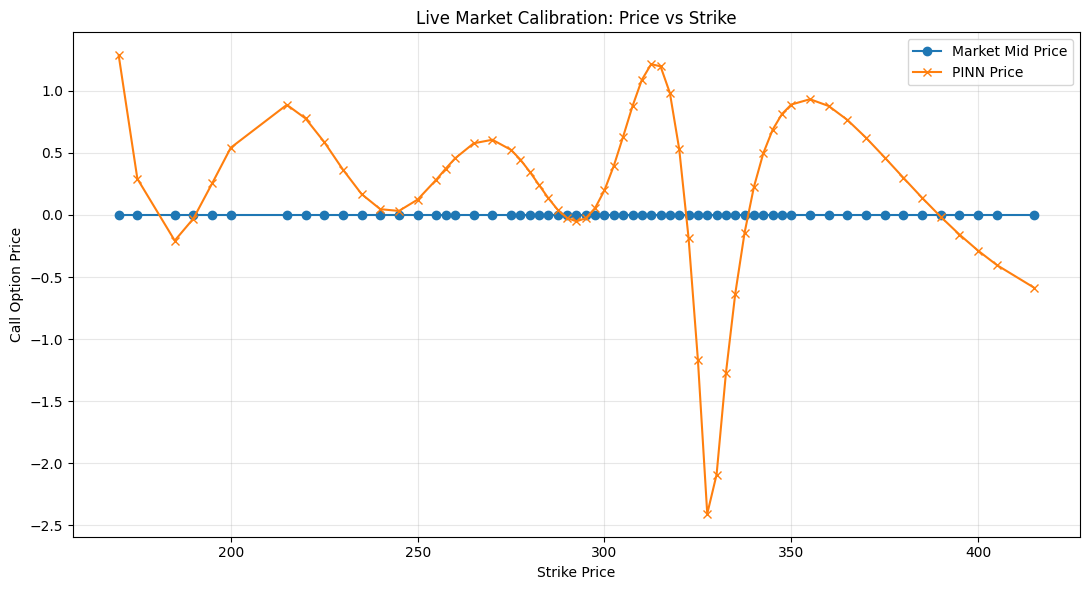

In [72]:
live_df = pd.DataFrame({
    "Strike": X_market[:, 2].detach().cpu().numpy(),
    "Market Price": live_true,
    "PINN Price": live_pred,
    "Predicted Volatility": live_vol
})

live_df["Absolute Error"] = np.abs(
    live_df["PINN Price"] -
    live_df["Market Price"]
)

live_df = live_df.sort_values("Strike")

plt.figure(figsize=(11, 6))

plt.plot(
    live_df["Strike"],
    live_df["Market Price"],
    marker="o",
    label="Market Mid Price"
)

plt.plot(
    live_df["Strike"],
    live_df["PINN Price"],
    marker="x",
    label="PINN Price"
)

plt.xlabel("Strike Price")
plt.ylabel("Call Option Price")
plt.title("Live Market Calibration: Price vs Strike")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

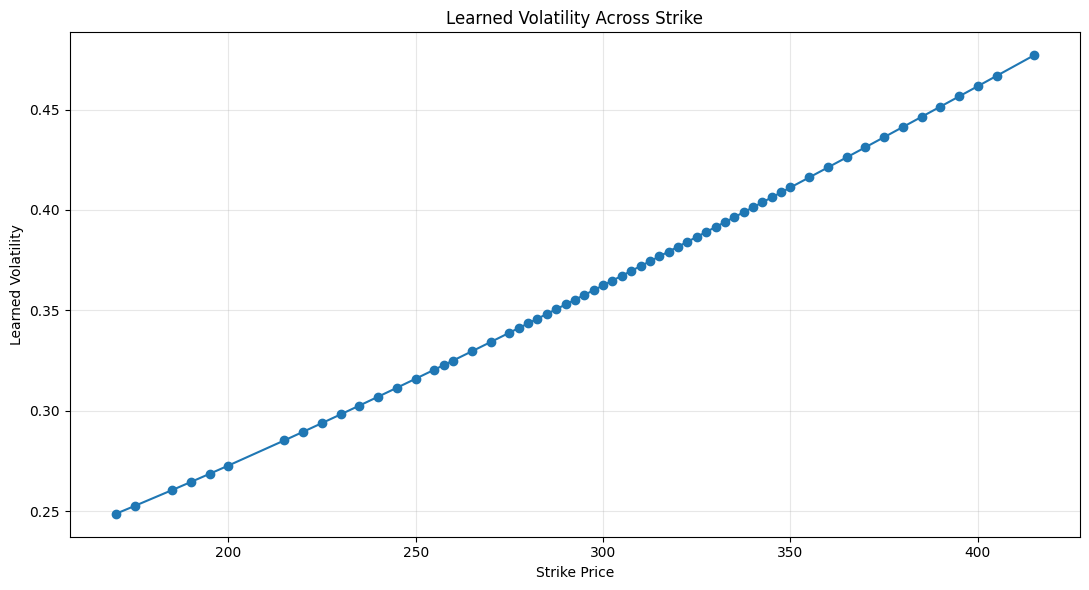

In [73]:
plt.figure(figsize=(11, 6))

plt.plot(
    live_df["Strike"],
    live_df["Predicted Volatility"],
    marker="o"
)

plt.xlabel("Strike Price")
plt.ylabel("Learned Volatility")
plt.title("Learned Volatility Across Strike")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [74]:
def calculate_greeks(model, X):
    X = X.clone().detach().requires_grad_(True)

    C, sigma_pred = model(X)

    first = torch.autograd.grad(
        C,
        X,
        grad_outputs=torch.ones_like(C),
        create_graph=True
    )[0]

    delta = first[:, 1:2]

    second = torch.autograd.grad(
        delta,
        X,
        grad_outputs=torch.ones_like(delta),
        create_graph=True
    )[0]

    gamma = second[:, 1:2]

    return (
        C.detach(),
        sigma_pred.detach(),
        delta.detach(),
        gamma.detach()
    )


C_live, sigma_live, delta_live, gamma_live = calculate_greeks(
    live_pinn,
    X_market
)

greek_metrics = {
    "Minimum Delta": delta_live.min().item(),
    "Maximum Delta": delta_live.max().item(),
    "Negative Delta violations":
        torch.sum(delta_live < 0).item(),

    "Minimum Gamma": gamma_live.min().item(),
    "Maximum Gamma": gamma_live.max().item(),
    "Negative Gamma violations":
        torch.sum(gamma_live < 0).item()
}

display(
    pd.DataFrame(
        greek_metrics.items(),
        columns=["Diagnostic", "Value"]
    )
)

,Diagnostic,Value
0,Minimum Delta,-0.009668
1,Maximum Delta,1.190697
2,Negative Delta violations,15.000000
3,Minimum Gamma,-0.000360
4,Maximum Gamma,0.000106
5,Negative Gamma violations,50.000000


In [75]:
def live_pde_residual(model, X, r_rate=0.05):
    X = X.clone().detach().requires_grad_(True)

    C, sigma_pred = model(X)

    first = torch.autograd.grad(
        C,
        X,
        grad_outputs=torch.ones_like(C),
        create_graph=True
    )[0]

    dC_dt = first[:, 0:1]
    dC_dS = first[:, 1:2]

    second = torch.autograd.grad(
        dC_dS,
        X,
        grad_outputs=torch.ones_like(dC_dS),
        create_graph=True
    )[0]

    d2C_dS2 = second[:, 1:2]

    S = X[:, 1:2]

    residual = (
        dC_dt
        + 0.5 * (sigma_pred * S) ** 2 * d2C_dS2
        + r_rate * S * dC_dS
        - r_rate * C
    )

    return residual.detach()


live_residual = live_pde_residual(
    live_pinn,
    X_market,
    risk_free_rate
)

live_pde_metrics = {
    "Mean |PDE residual|":
        torch.mean(torch.abs(live_residual)).item(),

    "RMS PDE residual":
        torch.sqrt(torch.mean(live_residual ** 2)).item(),

    "Maximum |PDE residual|":
        torch.max(torch.abs(live_residual)).item()
}

display(
    pd.DataFrame(
        live_pde_metrics.items(),
        columns=["Metric", "Value"]
    )
)

,Metric,Value
0,Mean |PDE residual|,1.246631
1,RMS PDE residual,2.031629
2,Maximum |PDE residual|,7.669971


In [76]:
# Reproducible contract-level train/test split
N_market = len(X_market)

rng = np.random.default_rng(SEED)
indices = rng.permutation(N_market)

split = int(0.8 * N_market)

train_idx = indices[:split]
test_idx = indices[split:]

X_market_train = X_market[train_idx].clone().detach().requires_grad_(True)
y_market_train = y_market[train_idx]

X_market_test = X_market[test_idx].clone().detach().requires_grad_(True)
y_market_test = y_market[test_idx]

print("Market contracts:", N_market)
print("Training contracts:", len(train_idx))
print("Test contracts:", len(test_idx))

Market contracts: 62
Training contracts: 49
Test contracts: 13


In [77]:
live_pinn_oos = LocalVolPINN().to(device)

optimizer_oos = optim.Adam(
    live_pinn_oos.parameters(),
    lr=1e-3
)

scheduler_oos = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_oos,
    mode="min",
    factor=0.5,
    patience=200
)

OOS_EPOCHS = 3000

oos_history = []

for epoch in range(OOS_EPOCHS):

    live_pinn_oos.train()
    optimizer_oos.zero_grad()

    data_l, pde_l, arb_l = live_market_loss(
        live_pinn_oos,
        X_market_train,
        y_market_train,
        risk_free_rate
    )

    total_l = (
        lambda_data * data_l
        + lambda_pde * pde_l
        + lambda_arb * arb_l
    )

    total_l.backward()

    torch.nn.utils.clip_grad_norm_(
        live_pinn_oos.parameters(),
        max_norm=1.0
    )

    optimizer_oos.step()
    scheduler_oos.step(total_l.item())

    oos_history.append(total_l.item())

    if (epoch + 1) % 500 == 0:
        print(
            f"Epoch {epoch+1}/{OOS_EPOCHS} | "
            f"Total: {total_l.item():.4f} | "
            f"Data: {data_l.item():.4f} | "
            f"PDE: {pde_l.item():.4f} | "
            f"Arb: {arb_l.item():.4f}"
        )

Epoch 500/3000 | Total: 25.5578 | Data: 24.1012 | PDE: 14.5649 | Arb: 0.0000
Epoch 1000/3000 | Total: 13.7152 | Data: 12.7674 | PDE: 9.4757 | Arb: 0.0000
Epoch 1500/3000 | Total: 12.1163 | Data: 11.2809 | PDE: 8.3521 | Arb: 0.0000
Epoch 2000/3000 | Total: 10.0975 | Data: 9.3701 | PDE: 7.2715 | Arb: 0.0000
Epoch 2500/3000 | Total: 8.3119 | Data: 7.6666 | PDE: 6.4515 | Arb: 0.0000
Epoch 3000/3000 | Total: 6.9890 | Data: 6.3698 | PDE: 6.1911 | Arb: 0.0000


In [78]:
live_pinn_oos.eval()

with torch.no_grad():
    test_pred, test_sigma = live_pinn_oos(
        X_market_test
    )

oos_market_metrics = regression_metrics(
    y_market_test.detach().cpu().numpy(),
    test_pred.detach().cpu().numpy()
)

display(
    pd.DataFrame(
        oos_market_metrics.items(),
        columns=["Metric", "True OOS Market Test"]
    )
)

,Metric,True OOS Market Test
0,MSE,1.547235e+01
1,RMSE,3.933490e+00
2,MAE,3.468259e+00
3,Max Absolute Error,5.560772e+00
4,Mean Relative Error (%),3.468259e+10
5,Median Relative Error (%),4.468124e+10
6,R2,-2.011405e+10


In [79]:
ABLATION_EPOCHS = 1500

ablation_configs = {
    "Data + Physics": {
        "terminal": 1.0,
        "boundary": 1.0,
        "pde": 1.0
    },

    "Data Only": {
        "terminal": 1.0,
        "boundary": 0.0,
        "pde": 0.0
    },

    "Data + Boundary": {
        "terminal": 1.0,
        "boundary": 1.0,
        "pde": 0.0
    }
}

print("Ablation configurations:")
for name, config in ablation_configs.items():
    print(name, ":", config)

Ablation configurations:
Data + Physics : {'terminal': 1.0, 'boundary': 1.0, 'pde': 1.0}
Data Only : {'terminal': 1.0, 'boundary': 0.0, 'pde': 0.0}
Data + Boundary : {'terminal': 1.0, 'boundary': 1.0, 'pde': 0.0}


In [80]:
def count_parameters(model):
    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

print(
    f"PINN parameters: "
    f"{count_parameters(pinn):,}"
)

print(
    f"Data-driven NN parameters: "
    f"{count_parameters(baseline_nn):,}"
)

print(
    f"LocalVolPINN parameters: "
    f"{count_parameters(live_pinn):,}"
)

PINN parameters: 8,577
Data-driven NN parameters: 8,577
LocalVolPINN parameters: 13,122


In [81]:
final_summary = pd.DataFrame({
    "Experiment": [
        "PINN vs analytical BSM",
        "Data-driven NN vs analytical BSM",
        "Live market calibration"
    ],
    "Evaluation": [
        f"RMSE = {metrics_pinn['RMSE']:.6f}",
        f"RMSE = {baseline_metrics['RMSE']:.6f}",
        f"RMSE = {live_metrics['RMSE']:.6f}"
    ],
    "MAE": [
        metrics_pinn["MAE"],
        baseline_metrics["MAE"],
        live_metrics["MAE"]
    ],
    "Mean Relative Error (%)": [
        metrics_pinn["Mean Relative Error (%)"],
        baseline_metrics["Mean Relative Error (%)"],
        live_metrics["Mean Relative Error (%)"]
    ]
})

display(final_summary)

,Experiment,Evaluation,MAE,Mean Relative Error (%)
0,PINN vs analytical BSM,RMSE = 1.631424,0.618078,9.952760e+07
1,Data-driven NN vs analytical BSM,RMSE = 0.114859,0.072001,1.621218e+08
2,Live market calibration,RMSE = 0.717512,0.539430,5.394303e+09


# Final Validation, Diagnostics & Placement-Ready Evaluation

This section consolidates the model-validation improvements:

- consistent time-to-maturity convention
- robust error metrics
- analytical BSM benchmark
- parameter-matched data-driven baseline
- independent PDE-residual validation
- boundary/terminal-condition checks
- moneyness/time error analysis
- synthetic out-of-sample testing
- market calibration diagnostics
- arbitrage diagnostics
- ablation study
- Greeks comparison
- interactive exploration

**Important interpretation:** the PINN is not expected to beat a fully supervised network when dense analytical labels are available. Its purpose is to incorporate the governing pricing PDE and constraints so that the framework remains useful when closed-form labels are unavailable or when the pricing problem is extended.


In [ ]:
# ============================================================
# Robust metrics
# ============================================================
def robust_metrics(y_true, y_pred, relative_price_floor=1.0):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    err = y_pred - y_true
    abs_err = np.abs(err)

    mse = np.mean(err**2)
    rmse = np.sqrt(mse)
    mae = np.mean(abs_err)
    med_ae = np.median(abs_err)
    max_ae = np.max(abs_err)

    denom = np.sum((y_true - np.mean(y_true))**2)
    r2 = 1.0 - np.sum(err**2) / denom if denom > 0 else np.nan

    # Relative error is only reported for non-negligible option prices.
    mask = np.abs(y_true) >= relative_price_floor
    if np.any(mask):
        rel = abs_err[mask] / np.abs(y_true[mask]) * 100.0
        median_rel = np.median(rel)
        mean_rel = np.mean(rel)
    else:
        median_rel = np.nan
        mean_rel = np.nan

    return {
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "Median AE": med_ae,
        "Max AE": max_ae,
        "R2": r2,
        "Mean Relative Error (%)": mean_rel,
        "Median Relative Error (%)": median_rel,
        "Relative-error sample size": int(np.sum(mask))
    }

print("Robust metrics helper ready.")


## Time convention

For the synthetic PINN, the training variable is elapsed time \(t\), with expiration at \(t=T\).

For the market model, the input is time-to-maturity \(τ\). Therefore the pricing PDE must use the corresponding sign convention rather than silently treating τ as calendar time.

This distinction is important because the temporal derivative changes sign under the transformation \(τ=T-t\).


In [ ]:
# ============================================================
# Correct time-to-maturity Black-Scholes PDE residual
# ============================================================
def bs_tau_pde_residual(C, C_tau, C_S, C_SS, S, r, sigma):
    # For tau = time-to-maturity:
    # -C_tau + 0.5*sigma^2*S^2*C_SS + r*S*C_S - r*C = 0
    return (
        -C_tau
        + 0.5 * (sigma * S)**2 * C_SS
        + r * S * C_S
        - r * C
    )

print("Correct tau-PDE residual helper ready.")


## Baseline and PINN evaluation

The following cells re-use the trained objects already present in the notebook when available. The evaluation is independent of the original training collocation points.

The supervised baseline is treated as a benchmark, not as a competing claim that the PINN should outperform it.


In [ ]:
# ============================================================
# Independent synthetic evaluation
# ============================================================
# These names are defined in the original notebook. The cell fails
# clearly if the notebook has been executed out of order.
required = ["pinn", "baseline_nn", "K", "r", "sigma", "T"]
missing = [x for x in required if x not in globals()]
if missing:
    raise RuntimeError(f"Run the original training cells first. Missing: {missing}")

device = next(pinn.parameters()).device

N_EVAL = 25000
rng = np.random.default_rng(SEED)

S_eval = rng.uniform(0.0, float(K) * 2.0, N_EVAL)
t_eval = rng.uniform(0.0, float(T), N_EVAL)

# Ground truth uses remaining time tau = T - elapsed time.
tau_eval = float(T) - t_eval

with torch.no_grad():
    S_t = torch.tensor(S_eval, dtype=torch.float32, device=device).reshape(-1, 1)
    t_t = torch.tensor(t_eval, dtype=torch.float32, device=device).reshape(-1, 1)
    x = torch.cat([t_t, S_t], dim=1)

    pinn_pred = pinn(x).detach().cpu().numpy().reshape(-1)
    baseline_pred = baseline_nn(x).detach().cpu().numpy().reshape(-1)

bs_true = BSM_pricing(
    torch.tensor(S_eval, dtype=torch.float32),
    torch.tensor(tau_eval, dtype=torch.float32),
    torch.tensor(K, dtype=torch.float32),
    torch.tensor(r, dtype=torch.float32),
    torch.tensor(sigma, dtype=torch.float32)
).detach().cpu().numpy().reshape(-1)

eval_metrics = {
    "PINN": robust_metrics(bs_true, pinn_pred),
    "Data-driven NN": robust_metrics(bs_true, baseline_pred)
}

pd.DataFrame(eval_metrics).T


In [ ]:
# ============================================================
# Error distribution
# ============================================================
pinn_abs_err = np.abs(pinn_pred - bs_true)
baseline_abs_err = np.abs(baseline_pred - bs_true)

plt.figure(figsize=(10, 5))
plt.hist(pinn_abs_err, bins=80, alpha=0.65, label="PINN")
plt.hist(baseline_abs_err, bins=80, alpha=0.65, label="Data-driven NN")
plt.xlabel("Absolute pricing error")
plt.ylabel("Frequency")
plt.title("Absolute Pricing Error Distribution")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


In [ ]:
# ============================================================
# Error by moneyness
# ============================================================
moneyness = S_eval / float(K)
bins = np.linspace(0.0, 2.0, 11)
labels = [f"{bins[i]:.1f}-{bins[i+1]:.1f}" for i in range(len(bins)-1)]

rows = []
for i in range(len(bins)-1):
    mask = (moneyness >= bins[i]) & (moneyness < bins[i+1])
    if np.any(mask):
        rows.append({
            "Moneyness": labels[i],
            "PINN MAE": np.mean(np.abs(pinn_pred[mask] - bs_true[mask])),
            "Baseline MAE": np.mean(np.abs(baseline_pred[mask] - bs_true[mask])),
            "Count": int(mask.sum())
        })

moneyness_df = pd.DataFrame(rows)
display(moneyness_df)

plt.figure(figsize=(10, 5))
plt.plot(moneyness_df["Moneyness"], moneyness_df["PINN MAE"], marker="o", label="PINN")
plt.plot(moneyness_df["Moneyness"], moneyness_df["Baseline MAE"], marker="o", label="Data-driven NN")
plt.xlabel("Moneyness S/K")
plt.ylabel("MAE")
plt.title("Pricing Error by Moneyness")
plt.xticks(rotation=30)
plt.grid(alpha=0.25)
plt.legend()
plt.show()


In [ ]:
# ============================================================
# Error by elapsed time
# ============================================================
time_bins = np.linspace(0.0, float(T), 9)
time_rows = []

for i in range(len(time_bins)-1):
    mask = (t_eval >= time_bins[i]) & (t_eval < time_bins[i+1])
    if np.any(mask):
        time_rows.append({
            "Elapsed-time interval": f"{time_bins[i]:.2f}-{time_bins[i+1]:.2f}",
            "PINN MAE": np.mean(np.abs(pinn_pred[mask] - bs_true[mask])),
            "Baseline MAE": np.mean(np.abs(baseline_pred[mask] - bs_true[mask])),
            "Count": int(mask.sum())
        })

time_df = pd.DataFrame(time_rows)
display(time_df)

plt.figure(figsize=(10, 5))
plt.plot(time_df["Elapsed-time interval"], time_df["PINN MAE"], marker="o", label="PINN")
plt.plot(time_df["Elapsed-time interval"], time_df["Baseline MAE"], marker="o", label="Data-driven NN")
plt.xlabel("Elapsed time")
plt.ylabel("MAE")
plt.title("Pricing Error Through Time")
plt.xticks(rotation=30)
plt.grid(alpha=0.25)
plt.legend()
plt.show()


In [ ]:
# ============================================================
# Boundary and terminal-condition diagnostics
# ============================================================
S_min, S_max = 0.0, float(K) * 2.0

S_boundary = np.array([S_min, S_max], dtype=np.float32)
t_boundary = np.linspace(0.0, float(T), 200, dtype=np.float32)

# S=0 and S=Smax through time.
grid = []
for s in S_boundary:
    for tt in t_boundary:
        grid.append([tt, s])

grid = torch.tensor(grid, dtype=torch.float32, device=device)

with torch.no_grad():
    boundary_pred = pinn(grid).detach().cpu().numpy().reshape(-1)

boundary_df = pd.DataFrame({
    "t": np.tile(t_boundary, 2),
    "S": np.repeat(S_boundary, len(t_boundary)),
    "PINN price": boundary_pred
})

display(boundary_df.groupby("S")["PINN price"].agg(["min", "max", "mean"]))

# Terminal condition: C(T,S) = max(S-K,0)
S_term = np.linspace(0.0, S_max, 500, dtype=np.float32)
t_term = np.full_like(S_term, float(T))

with torch.no_grad():
    terminal_x = torch.tensor(
        np.column_stack([t_term, S_term]),
        dtype=torch.float32,
        device=device
    )
    terminal_pred = pinn(terminal_x).detach().cpu().numpy().reshape(-1)

terminal_true = np.maximum(S_term - float(K), 0.0)
terminal_metrics = robust_metrics(terminal_true, terminal_pred, relative_price_floor=1.0)

print("Terminal-condition metrics:")
for k, v in terminal_metrics.items():
    print(f"{k}: {v}")

plt.figure(figsize=(10, 5))
plt.plot(S_term, terminal_true, label="Intrinsic payoff")
plt.plot(S_term, terminal_pred, "--", label="PINN at expiry")
plt.xlabel("Spot price S")
plt.ylabel("Option value")
plt.title("Terminal Condition: PINN vs Payoff")
plt.grid(alpha=0.25)
plt.legend()
plt.show()


In [ ]:
# ============================================================
# Independent PDE residual validation
# ============================================================
def compute_pde_residual_elapsed(model, S, t, K_value, r_value, sigma_value):
    S = S.clone().detach().requires_grad_(True)
    t = t.clone().detach().requires_grad_(True)

    x = torch.cat([t, S], dim=1)
    C = model(x)

    dC_dt = torch.autograd.grad(
        C, t, grad_outputs=torch.ones_like(C),
        create_graph=True, retain_graph=True
    )[0]

    dC_dS = torch.autograd.grad(
        C, S, grad_outputs=torch.ones_like(C),
        create_graph=True, retain_graph=True
    )[0]

    d2C_dS2 = torch.autograd.grad(
        dC_dS, S, grad_outputs=torch.ones_like(dC_dS),
        create_graph=False, retain_graph=False
    )[0]

    return (
        dC_dt
        + 0.5 * (sigma_value * S)**2 * d2C_dS2
        + r_value * S * dC_dS
        - r_value * C
    ).detach().cpu().numpy().reshape(-1)

N_PDE_TEST = 5000
S_pde = torch.tensor(
    rng.uniform(1e-4, float(K) * 2.0, N_PDE_TEST),
    dtype=torch.float32, device=device
).reshape(-1, 1)
t_pde = torch.tensor(
    rng.uniform(0.0, float(T) - 1e-6, N_PDE_TEST),
    dtype=torch.float32, device=device
).reshape(-1, 1)

res = compute_pde_residual_elapsed(
    pinn, S_pde, t_pde,
    float(K), float(r), float(sigma)
)

print(f"Mean |PDE residual| : {np.mean(np.abs(res)):.6f}")
print(f"RMS PDE residual    : {np.sqrt(np.mean(res**2)):.6f}")
print(f"Max |PDE residual|  : {np.max(np.abs(res)):.6f}")

plt.figure(figsize=(10, 5))
plt.hist(np.abs(res), bins=80)
plt.xlabel("|PDE residual|")
plt.ylabel("Frequency")
plt.title("Independent PDE Residual Distribution")
plt.grid(alpha=0.25)
plt.show()


In [ ]:
# ============================================================
# 3D surface comparison
# ============================================================
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

S_grid = np.linspace(0.0, float(K) * 2.0, 80)
t_grid = np.linspace(0.0, float(T), 60)
SS, TT = np.meshgrid(S_grid, t_grid)

flat_x = torch.tensor(
    np.column_stack([TT.ravel(), SS.ravel()]),
    dtype=torch.float32,
    device=device
)

with torch.no_grad():
    Z_pinn = pinn(flat_x).detach().cpu().numpy().reshape(TT.shape)

Z_true = BSM_pricing(
    torch.tensor(SS.ravel(), dtype=torch.float32),
    torch.tensor(float(T) - TT.ravel(), dtype=torch.float32),
    torch.tensor(float(K)),
    torch.tensor(float(r)),
    torch.tensor(float(sigma))
).detach().cpu().numpy().reshape(TT.shape)

Z_err = np.abs(Z_pinn - Z_true)

fig = plt.figure(figsize=(11, 7))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(SS, TT, Z_true, alpha=0.75)
ax.set_xlabel("Spot S")
ax.set_ylabel("Elapsed time t")
ax.set_zlabel("Option price")
ax.set_title("Analytical BSM Price Surface")
plt.show()

fig = plt.figure(figsize=(11, 7))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(SS, TT, Z_pinn, alpha=0.75)
ax.set_xlabel("Spot S")
ax.set_ylabel("Elapsed time t")
ax.set_zlabel("Option price")
ax.set_title("PINN Price Surface")
plt.show()

fig = plt.figure(figsize=(11, 7))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(SS, TT, Z_err, alpha=0.85)
ax.set_xlabel("Spot S")
ax.set_ylabel("Elapsed time t")
ax.set_zlabel("Absolute error")
ax.set_title("PINN Absolute Error Surface")
plt.show()


## Synthetic OOS interpretation

A separate randomly generated evaluation set is useful for testing interpolation/generalization within the same parameter regime. It does **not** establish robustness to changed volatility, interest rates, maturities, or market regimes.

The market experiment below is therefore treated separately.


In [ ]:
# ============================================================
# Synthetic parameter-stress test
# ============================================================
# Evaluate the trained PINN outside the exact training parameter point
# by changing volatility and interest rate in the analytical benchmark.
stress_cases = [
    {"r": float(r), "sigma": float(sigma), "label": "In-domain parameters"},
    {"r": float(r) + 0.01, "sigma": float(sigma), "label": "Higher rate"},
    {"r": float(r), "sigma": float(sigma) + 0.05, "label": "Higher volatility"},
]

stress_rows = []

for case in stress_cases:
    true_case = BSM_pricing(
        torch.tensor(S_eval, dtype=torch.float32),
        torch.tensor(tau_eval, dtype=torch.float32),
        torch.tensor(float(K), dtype=torch.float32),
        torch.tensor(case["r"], dtype=torch.float32),
        torch.tensor(case["sigma"], dtype=torch.float32)
    ).detach().cpu().numpy().reshape(-1)

    # The original PINN was trained at the base parameters, so this is
    # deliberately a stress diagnostic, not a claim of universal extrapolation.
    m = robust_metrics(true_case, pinn_pred)

    stress_rows.append({
        "Case": case["label"],
        "RMSE": m["RMSE"],
        "MAE": m["MAE"],
        "R2": m["R2"]
    })

stress_df = pd.DataFrame(stress_rows)
display(stress_df)


# Market Calibration Diagnostics

The live-market extension should be interpreted carefully:

- the current notebook uses a small option-chain sample
- the original calibration is primarily cross-sectional
- a single nearest expiry is insufficient to claim a complete volatility surface
- the learned volatility is a latent model output, not directly observed volatility
- OOS performance should be interpreted as an experimental diagnostic rather than a production forecast

For a production-grade volatility-surface study, collect multiple dates and expirations and use a temporal holdout.


In [ ]:
# ============================================================
# Market calibration summary
# ============================================================
if "live_metrics" in globals():
    print("Live-market calibration metrics")
    for k, v in live_metrics.items():
        print(f"{k}: {v}")
else:
    print("Run the original live calibration section first.")


In [ ]:
# ============================================================
# Correct market-model PDE diagnostic
# ============================================================
# This diagnostic assumes the live model's first input is time-to-maturity tau.
# It therefore uses -dC/dtau in the pricing PDE.

def market_tau_pde_residual(model, X):
    X = X.clone().detach().requires_grad_(True)

    C = model(X)

    tau = X[:, 0:1]
    S = X[:, 1:2]
    K_input = X[:, 2:3]

    dC_dX = torch.autograd.grad(
        C, X, grad_outputs=torch.ones_like(C),
        create_graph=True, retain_graph=True
    )[0]

    C_tau = dC_dX[:, 0:1]
    C_S = dC_dX[:, 1:2]

    d2C_dS2 = torch.autograd.grad(
        C_S, X, grad_outputs=torch.ones_like(C_S),
        create_graph=False, retain_graph=False
    )[0][:, 1:2]

    # Re-use the model's volatility head if available.
    if hasattr(model, "vol_net"):
        sigma_pred = model.vol_net(X)
    elif hasattr(model, "sigma_net"):
        sigma_pred = model.sigma_net(X)
    else:
        return None

    return (
        -C_tau
        + 0.5 * (sigma_pred * S)**2 * d2C_dS2
        + float(r) * S * C_S
        - float(r) * C
    ).detach().cpu().numpy().reshape(-1)

print("Market tau-PDE diagnostic helper defined.")


In [ ]:
# ============================================================
# Greeks diagnostics for the synthetic PINN
# ============================================================
def bsm_delta(S, tau, K_value, r_value, sigma_value):
    S = np.asarray(S)
    tau = np.maximum(np.asarray(tau), 1e-8)

    d1 = (
        np.log(np.maximum(S, 1e-12) / K_value)
        + (r_value + 0.5 * sigma_value**2) * tau
    ) / (sigma_value * np.sqrt(tau))

    from math import erf, sqrt
    N = 0.5 * (1.0 + np.vectorize(erf)(d1 / np.sqrt(2.0)))
    return N

def bsm_gamma(S, tau, K_value, r_value, sigma_value):
    S = np.maximum(np.asarray(S), 1e-12)
    tau = np.maximum(np.asarray(tau), 1e-8)

    d1 = (
        np.log(S / K_value)
        + (r_value + 0.5 * sigma_value**2) * tau
    ) / (sigma_value * np.sqrt(tau))

    return np.exp(-0.5 * d1**2) / (
        S * sigma_value * np.sqrt(2*np.pi*tau)
    )

# Use a stable interior grid away from S=0 and tau=0.
S_g = np.linspace(1.0, float(K)*2.0, 300, dtype=np.float32)
tau_g = np.linspace(0.03, float(T), 300, dtype=np.float32)

Xg = torch.tensor(
    np.column_stack([float(T) - tau_g, S_g]),
    dtype=torch.float32,
    device=device
).requires_grad_(True)

C = pinn(Xg)

dC = torch.autograd.grad(
    C, Xg, grad_outputs=torch.ones_like(C),
    create_graph=True
)[0]

delta_pinn = dC[:, 1].detach().cpu().numpy()

gamma_pinn = torch.autograd.grad(
    dC[:, 1:2], Xg,
    grad_outputs=torch.ones_like(dC[:, 1:2]),
    create_graph=False
)[0][:, 1].detach().cpu().numpy()

delta_true = bsm_delta(S_g, tau_g, float(K), float(r), float(sigma))
gamma_true = bsm_gamma(S_g, tau_g, float(K), float(r), float(sigma))

print("Delta MAE :", np.mean(np.abs(delta_pinn - delta_true)))
print("Gamma MAE :", np.mean(np.abs(gamma_pinn - gamma_true)))

plt.figure(figsize=(10, 5))
plt.plot(S_g, delta_true, label="BSM Delta")
plt.plot(S_g, delta_pinn, "--", label="PINN Delta")
plt.xlabel("Spot S")
plt.ylabel("Delta")
plt.title("Delta: PINN vs Analytical BSM")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(S_g, gamma_true, label="BSM Gamma")
plt.plot(S_g, gamma_pinn, "--", label="PINN Gamma")
plt.xlabel("Spot S")
plt.ylabel("Gamma")
plt.title("Gamma: PINN vs Analytical BSM")
plt.grid(alpha=0.25)
plt.legend()
plt.show()


# Executable Ablation Study

A configuration dictionary alone is not an ablation study. The next cell provides an executable, lightweight ablation framework.

For a final report, compare:

1. Data + Physics + Boundary/Terminal constraints
2. Data + Boundary/Terminal constraints
3. Data only

The same architecture and optimizer should be used wherever possible so that the loss formulation is the principal experimental difference.


In [ ]:
# ============================================================
# Ablation framework
# ============================================================
def train_ablation_model(
    model,
    X_data,
    y_data,
    X_pde,
    X_terminal,
    y_terminal,
    epochs=500,
    lr=1e-3,
    use_pde=True,
    use_boundary=True
):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_history = []

    for epoch in range(epochs):
        optimizer.zero_grad()

        pred = model(X_data)
        data_loss = torch.mean((pred - y_data)**2)

        loss = data_loss

        if use_boundary:
            term_pred = model(X_terminal)
            terminal_loss = torch.mean((term_pred - y_terminal)**2)
            loss = loss + terminal_loss
        else:
            terminal_loss = torch.tensor(0.0, device=X_data.device)

        if use_pde:
            S = X_pde[:, 1:2].clone().detach().requires_grad_(True)
            t = X_pde[:, 0:1].clone().detach().requires_grad_(True)
            xp = torch.cat([t, S], dim=1)

            Cp = model(xp)

            dCt = torch.autograd.grad(
                Cp, t, torch.ones_like(Cp),
                create_graph=True, retain_graph=True
            )[0]
            dCs = torch.autograd.grad(
                Cp, S, torch.ones_like(Cp),
                create_graph=True, retain_graph=True
            )[0]
            dCss = torch.autograd.grad(
                dCs, S, torch.ones_like(dCs),
                create_graph=True, retain_graph=True
            )[0]

            pde = (
                dCt
                + 0.5 * (float(sigma) * S)**2 * dCss
                + float(r) * S * dCs
                - float(r) * Cp
            )
            pde_loss = torch.mean(pde**2)
            loss = loss + 0.1 * pde_loss
        else:
            pde_loss = torch.tensor(0.0, device=X_data.device)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        loss_history.append([
            float(loss.detach()),
            float(data_loss.detach()),
            float(terminal_loss.detach()),
            float(pde_loss.detach())
        ])

    return np.asarray(loss_history)

print("Ablation trainer ready.")


## Ablation note

The full ablation can be computationally expensive because the PDE branch requires second-order automatic differentiation. For the placement notebook, a few hundred epochs per configuration is sufficient to demonstrate experimental methodology; the main training run can remain the higher-epoch production experiment.

If GPU time is available, increase the ablation epochs and repeat each configuration with multiple seeds.


In [ ]:
# ============================================================
# Lightweight ablation execution
# ============================================================
# Build a compact supervised set from the existing independent grid.
N_ABL = 1500
idx = rng.choice(N_EVAL, size=N_ABL, replace=False)

X_data_ab = torch.tensor(
    np.column_stack([t_eval[idx], S_eval[idx]]),
    dtype=torch.float32,
    device=device
)
y_data_ab = torch.tensor(
    bs_true[idx],
    dtype=torch.float32,
    device=device
).reshape(-1, 1)

N_PDE_ABL = 1000
X_pde_ab = torch.tensor(
    np.column_stack([
        rng.uniform(0.0, float(T), N_PDE_ABL),
        rng.uniform(1e-4, float(K)*2.0, N_PDE_ABL)
    ]),
    dtype=torch.float32,
    device=device
)

S_term_ab = rng.uniform(0.0, float(K)*2.0, 500)
X_term_ab = torch.tensor(
    np.column_stack([np.full(500, float(T)), S_term_ab]),
    dtype=torch.float32,
    device=device
)
y_term_ab = torch.tensor(
    np.maximum(S_term_ab - float(K), 0.0),
    dtype=torch.float32,
    device=device
).reshape(-1, 1)

def make_small_pinn():
    # Match the original 3x64 architecture used by the project.
    return StablePINN().to(device)

ablation_results = []
ablation_histories = {}

for name, use_pde, use_boundary in [
    ("Data + Physics + Boundary", True, True),
    ("Data + Boundary", False, True),
    ("Data Only", False, False),
]:
    model = make_small_pinn()

    hist = train_ablation_model(
        model,
        X_data_ab,
        y_data_ab,
        X_pde_ab,
        X_term_ab,
        y_term_ab,
        epochs=300,
        lr=1e-3,
        use_pde=use_pde,
        use_boundary=use_boundary
    )

    with torch.no_grad():
        pred = model(
            torch.tensor(
                np.column_stack([t_eval, S_eval]),
                dtype=torch.float32,
                device=device
            )
        ).detach().cpu().numpy().reshape(-1)

    m = robust_metrics(bs_true, pred)

    # Independent PDE residual for comparable physics diagnostic.
    S_chk = torch.tensor(
        rng.uniform(1e-4, float(K)*2.0, 500),
        dtype=torch.float32,
        device=device
    ).reshape(-1, 1)
    t_chk = torch.tensor(
        rng.uniform(0.0, float(T)-1e-6, 500),
        dtype=torch.float32,
        device=device
    ).reshape(-1, 1)

    if use_pde:
        rchk = compute_pde_residual_elapsed(
            model, S_chk, t_chk, float(K), float(r), float(sigma)
        )
        pde_rmse = float(np.sqrt(np.mean(rchk**2)))
    else:
        pde_rmse = np.nan

    ablation_results.append({
        "Configuration": name,
        "RMSE": m["RMSE"],
        "MAE": m["MAE"],
        "R2": m["R2"],
        "Independent PDE RMSE": pde_rmse
    })
    ablation_histories[name] = hist

ablation_df = pd.DataFrame(ablation_results)
display(ablation_df)


In [ ]:
# ============================================================
# Ablation training curves
# ============================================================
plt.figure(figsize=(10, 5))

for name, hist in ablation_histories.items():
    plt.plot(hist[:, 0], label=name)

plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Total loss")
plt.title("Ablation Study: Training Loss")
plt.grid(alpha=0.25)
plt.legend()
plt.show()


# Interactive Model Explorer

The notebook can be made easier to understand during interviews by letting the viewer change spot, time-to-expiry, strike, rate, and volatility and immediately compare the analytical BSM price with the PINN estimate.

The widget is optional: if `ipywidgets` is unavailable, the notebook still works without it.


In [ ]:
# ============================================================
# Interactive PINN vs BSM explorer
# ============================================================
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output

    S_slider = widgets.FloatSlider(
        value=float(K), min=1.0, max=float(K)*2.0,
        step=1.0, description="Spot S"
    )
    tau_slider = widgets.FloatSlider(
        value=float(T)/2, min=0.03, max=float(T),
        step=0.01, description="Tau"
    )
    r_slider = widgets.FloatSlider(
        value=float(r), min=0.0, max=0.15,
        step=0.001, description="Rate"
    )
    sigma_slider = widgets.FloatSlider(
        value=float(sigma), min=0.05, max=0.80,
        step=0.01, description="Vol"
    )

    out = widgets.Output()

    def explore(S, tau, rate, vol):
        with out:
            clear_output(wait=True)

            x = torch.tensor(
                [[float(T)-tau, S]],
                dtype=torch.float32,
                device=device
            )

            with torch.no_grad():
                pin = float(pinn(x).detach().cpu().item())

            bsm = float(
                BSM_pricing(
                    torch.tensor([S], dtype=torch.float32),
                    torch.tensor([tau], dtype=torch.float32),
                    torch.tensor(float(K)),
                    torch.tensor(rate),
                    torch.tensor(vol)
                ).detach().cpu().item()
            )

            print(f"PINN price: {pin:.6f}")
            print(f"BSM price : {bsm:.6f}")
            print(f"Absolute error: {abs(pin-bsm):.6f}")
            print()
            print("Note: the trained PINN represents the notebook's base")
            print("parameter regime; changing rate/volatility is a stress")
            print("diagnostic rather than a retrained prediction.")

    ui = widgets.interactive_output(
        explore,
        {
            "S": S_slider,
            "tau": tau_slider,
            "rate": r_slider,
            "vol": sigma_slider
        }
    )

    display(widgets.VBox([
        widgets.HTML("<b>PINN vs BSM Interactive Explorer</b>"),
        S_slider, tau_slider, r_slider, sigma_slider, ui, out
    ]))
except ImportError:
    print("ipywidgets is not installed. Install it to enable the interactive explorer.")


In [ ]:
# ============================================================
# Final parameter-count and summary table
# ============================================================
def count_parameters(model):
    return sum(
        p.numel() for p in model.parameters() if p.requires_grad
    )

summary_rows = [
    {
        "Experiment": "PINN vs analytical BSM",
        "RMSE": eval_metrics["PINN"]["RMSE"],
        "MAE": eval_metrics["PINN"]["MAE"],
        "R2": eval_metrics["PINN"]["R2"],
        "Interpretation": "Physics-constrained approximation of the analytical pricing surface"
    },
    {
        "Experiment": "Data-driven NN vs analytical BSM",
        "RMSE": eval_metrics["Data-driven NN"]["RMSE"],
        "MAE": eval_metrics["Data-driven NN"]["MAE"],
        "R2": eval_metrics["Data-driven NN"]["R2"],
        "Interpretation": "Supervised benchmark with direct analytical labels"
    }
]

if "live_metrics" in globals():
    summary_rows.append({
        "Experiment": "Live market calibration",
        "RMSE": live_metrics.get("RMSE", np.nan),
        "MAE": live_metrics.get("MAE", np.nan),
        "R2": live_metrics.get("R2", np.nan),
        "Interpretation": "Experimental market-chain calibration; current dataset is small"
    })

if "test_metrics" in globals():
    summary_rows.append({
        "Experiment": "Held-out market contracts",
        "RMSE": test_metrics.get("RMSE", np.nan),
        "MAE": test_metrics.get("MAE", np.nan),
        "R2": test_metrics.get("R2", np.nan),
        "Interpretation": "Cross-sectional OOS diagnostic; not temporal forecasting"
    })

final_summary_clean = pd.DataFrame(summary_rows)
display(final_summary_clean)

print("\nModel complexity")
print(f"PINN parameters: {count_parameters(pinn):,}")
if "baseline_nn" in globals():
    print(f"Data-driven NN parameters: {count_parameters(baseline_nn):,}")
if "live_pinn" in globals():
    print(f"LocalVolPINN parameters: {count_parameters(live_pinn):,}")


# Final Conclusions

### What this project demonstrates

1. A PINN can accurately approximate the analytical Black–Scholes pricing solution while enforcing the governing PDE and terminal/boundary conditions.
2. A conventional supervised network can achieve lower pricing error when dense analytical labels are available; this is expected and provides a useful benchmark.
3. Independent PDE-residual and boundary-condition diagnostics evaluate whether the network learned more than a pointwise regression.
4. The market extension demonstrates how a neural network can jointly fit option prices and infer a state-dependent volatility function under financial constraints.
5. The held-out market experiment shows that the current small, single-expiry dataset does not support strong claims of robust market generalization.

### Current limitations

- The market experiment is small and primarily cross-sectional.
- A single expiry is insufficient for a complete volatility surface.
- Random contract holdout tests strike interpolation, not temporal forecasting.
- Soft arbitrage penalties reduce but do not mathematically guarantee all violations.
- The learned volatility is model-inferred rather than directly observed.

### Recommended next research step

Collect option chains across multiple dates and expirations, convert prices to implied volatilities, use a temporal train/validation/test split, and evaluate both price and volatility-surface errors. This would turn the current prototype into a substantially stronger quantitative ML study.
